# Northgate AI Stock Predictor
### End-to-End Stock Prediction and Portfolio Optimization

In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import pyarrow

print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: c:\Users\sun\AppData\Local\Programs\Python\Python314\python.exe
NumPy: 2.5.3
Pandas: 3.0.5
Matplotlib: 3.11.1
Seaborn: 0.13.2
Scikit-learn: 1.9.0


In [4]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

print("Project root:", PROJECT_ROOT)
print("Processed data directory:", PROCESSED_DIR)
print("Results directory:", RESULTS_DIR)

Project root: c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor
Processed data directory: c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\processed
Results directory: c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results


In [5]:
features_path = PROCESSED_DIR / "features.parquet"

features_df = pd.read_parquet(features_path)

print("Dataset shape:", features_df.shape)
display(features_df.head())

Dataset shape: (2936, 288)


Price       Adj Close                                                         \
Ticker           AAPL        CAT         HD        JNJ        JPM         KO   
Date                                                                           
2015-01-02  24.171755  68.899345  78.204041  75.737366  46.066788  29.390263   
2015-01-05  23.490805  65.262398  76.563309  75.208389  44.636635  29.390263   
2015-01-06  23.493017  64.842461  76.328911  74.838837  43.479263  29.613441   
2015-01-07  23.822432  65.847313  78.945038  76.490990  43.545609  29.983099   
2015-01-08  24.737753  66.522217  80.691635  77.092400  44.518696  30.345751   

Price                                                  ...   Features  \
Ticker           MSFT      NVDA         PG        XOM  ... cpi_change   
Date                                                   ...              
2015-01-02  39.607178  0.482423  65.069992  56.777901  ...        NaN   
2015-01-05  39.242962  0.474275  64.760643  55.224365  ...        NaN   
2015-01-06  38.666973  0.459895  64.465637  54.930759  ...        NaN   
2015-01-07  39.158257  0.458697  64.803787  55.487362  ...        NaN   
2015-01-08  40.310219  0.475952  65.544853  56.410934  ...        NaN   

Price                                                                  \
Ticker     unemployment_change day_of_week month quarter day_of_month   
Date                                                                    
2015-01-02                 NaN           4     1       1            2   
2015-01-05                 NaN           0     1       1            5   
2015-01-06                 NaN           1     1       1            6   
2015-01-07                 NaN           2     1       1            7   
2015-01-08                 NaN           3     1       1            8   

Price                                                           
Ticker     month_sin month_cos day_of_week_sin day_of_week_cos  
Date                                                            
2015-01-02       0.5  0.866025       -0.951057        0.309017  
2015-01-05       0.5  0.866025        0.000000        1.000000  
2015-01-06       0.5  0.866025        0.951057        0.309017  
2015-01-07       0.5  0.866025        0.587785       -0.809017  
2015-01-08       0.5  0.866025       -0.587785       -0.809017  

[5 rows x 288 columns]

In [6]:
print("Columns type:", type(features_df.columns))
print("Index type:", type(features_df.index))

print("\nIndex:")
print(features_df.index)

print("\nMissing values:")
display(features_df.isnull().sum().sort_values(ascending=False).head(20))

Columns type: <class 'pandas.MultiIndex'>
Index type: <class 'pandas.DatetimeIndex'>

Index:
DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-08-24', '2026-08-25', '2026-08-26', '2026-08-27',
               '2026-08-28', '2026-08-31', '2026-09-01', '2026-09-02',
               '2026-09-03', '2026-09-04'],
              dtype='datetime64[ns]', name='Date', length=2936, freq=None)

Missing values:


Price     Ticker             
Features  HD_price_to_ma200      199
          CAT_price_to_ma200     199
          KO_price_to_ma200      199
          NVDA_price_to_ma200    199
          PG_price_to_ma200      199
          JNJ_price_to_ma200     199
          XOM_price_to_ma200     199
          JPM_price_to_ma200     199
          MSFT_price_to_ma200    199
          AAPL_price_to_ma200    199
          HD_ma_200              199
          CAT_ma_200             199
          KO_ma_200              199
          NVDA_ma_200            199
          PG_ma_200              199
          JNJ_ma_200             199
          XOM_ma_200             199
          JPM_ma_200             199
          MSFT_ma_200            199
          AAPL_ma_200            199
dtype: int64

In [7]:
if isinstance(features_df.columns, pd.MultiIndex):
    features_df.columns = [
        "_".join(
            str(level)
            for level in column
            if str(level).lower() != "nan"
        ).strip("_")
        for column in features_df.columns
    ]

features_df = features_df.reset_index()

if "date" not in features_df.columns:
    first_column = features_df.columns[0]
    features_df = features_df.rename(columns={first_column: "date"})

features_df["date"] = pd.to_datetime(features_df["date"])

print("Final shape:", features_df.shape)
display(features_df.head())

Final shape: (2936, 289)


,date,Adj Close_AAPL,Adj Close_CAT,Adj Close_HD,Adj Close_JNJ,Adj Close_JPM,Adj Close_KO,Adj Close_MSFT,Adj Close_NVDA,Adj Close_PG,...,Features_cpi_change,Features_unemployment_change,Features_day_of_week,Features_month,Features_quarter,Features_day_of_month,Features_month_sin,Features_month_cos,Features_day_of_week_sin,Features_day_of_week_cos
0,2015-01-02,24.171755,68.899345,78.204041,75.737366,46.066788,29.390263,39.607178,0.482423,65.069992,...,NaN,NaN,4,1,1,2,0.5,0.866025,-0.951057,0.309017
1,2015-01-05,23.490805,65.262398,76.563309,75.208389,44.636635,29.390263,39.242962,0.474275,64.760643,...,NaN,NaN,0,1,1,5,0.5,0.866025,0.000000,1.000000
2,2015-01-06,23.493017,64.842461,76.328911,74.838837,43.479263,29.613441,38.666973,0.459895,64.465637,...,NaN,NaN,1,1,1,6,0.5,0.866025,0.951057,0.309017
3,2015-01-07,23.822432,65.847313,78.945038,76.490990,43.545609,29.983099,39.158257,0.458697,64.803787,...,NaN,NaN,2,1,1,7,0.5,0.866025,0.587785,-0.809017
4,2015-01-08,24.737753,66.522217,80.691635,77.092400,44.518696,30.345751,40.310219,0.475952,65.544853,...,NaN,NaN,3,1,1,8,0.5,0.866025,-0.587785,-0.809017


In [8]:
print("Start date:", features_df["date"].min())
print("End date:", features_df["date"].max())

print("\nTotal columns:", len(features_df.columns))

for column in features_df.columns:
    print(column)

Start date: 2015-01-02 00:00:00
End date: 2026-09-04 00:00:00

Total columns: 289
date
Adj Close_AAPL
Adj Close_CAT
Adj Close_HD
Adj Close_JNJ
Adj Close_JPM
Adj Close_KO
Adj Close_MSFT
Adj Close_NVDA
Adj Close_PG
Adj Close_XOM
Adj Close_^GSPC
Adj Close_^VIX
Close_AAPL
Close_CAT
Close_HD
Close_JNJ
Close_JPM
Close_KO
Close_MSFT
Close_NVDA
Close_PG
Close_XOM
Close_^GSPC
Close_^VIX
High_AAPL
High_CAT
High_HD
High_JNJ
High_JPM
High_KO
High_MSFT
High_NVDA
High_PG
High_XOM
High_^GSPC
High_^VIX
Low_AAPL
Low_CAT
Low_HD
Low_JNJ
Low_JPM
Low_KO
Low_MSFT
Low_NVDA
Low_PG
Low_XOM
Low_^GSPC
Low_^VIX
Open_AAPL
Open_CAT
Open_HD
Open_JNJ
Open_JPM
Open_KO
Open_MSFT
Open_NVDA
Open_PG
Open_XOM
Open_^GSPC
Open_^VIX
Volume_AAPL
Volume_CAT
Volume_HD
Volume_JNJ
Volume_JPM
Volume_KO
Volume_MSFT
Volume_NVDA
Volume_PG
Volume_XOM
Volume_^GSPC
Volume_^VIX
Macro_DGS10
Macro_DGS3MO
Macro_CPIAUCSL
Macro_UNRATE
Features_AAPL_return_1d
Features_AAPL_return_5d
Features_AAPL_return_20d
Features_AAPL_return_60d
Features_MSF

In [9]:
# Dataset overview

print("Dataset shape:", features_df.shape)
print("Number of rows:", features_df.shape[0])
print("Number of columns:", features_df.shape[1])

display(features_df.head())

Dataset shape: (2936, 289)
Number of rows: 2936
Number of columns: 289


,date,Adj Close_AAPL,Adj Close_CAT,Adj Close_HD,Adj Close_JNJ,Adj Close_JPM,Adj Close_KO,Adj Close_MSFT,Adj Close_NVDA,Adj Close_PG,...,Features_cpi_change,Features_unemployment_change,Features_day_of_week,Features_month,Features_quarter,Features_day_of_month,Features_month_sin,Features_month_cos,Features_day_of_week_sin,Features_day_of_week_cos
0,2015-01-02,24.171755,68.899345,78.204041,75.737366,46.066788,29.390263,39.607178,0.482423,65.069992,...,NaN,NaN,4,1,1,2,0.5,0.866025,-0.951057,0.309017
1,2015-01-05,23.490805,65.262398,76.563309,75.208389,44.636635,29.390263,39.242962,0.474275,64.760643,...,NaN,NaN,0,1,1,5,0.5,0.866025,0.000000,1.000000
2,2015-01-06,23.493017,64.842461,76.328911,74.838837,43.479263,29.613441,38.666973,0.459895,64.465637,...,NaN,NaN,1,1,1,6,0.5,0.866025,0.951057,0.309017
3,2015-01-07,23.822432,65.847313,78.945038,76.490990,43.545609,29.983099,39.158257,0.458697,64.803787,...,NaN,NaN,2,1,1,7,0.5,0.866025,0.587785,-0.809017
4,2015-01-08,24.737753,66.522217,80.691635,77.092400,44.518696,30.345751,40.310219,0.475952,65.544853,...,NaN,NaN,3,1,1,8,0.5,0.866025,-0.587785,-0.809017


In [10]:
# Data types

display(features_df.dtypes.value_counts())

# Missing values

missing_values = (
    features_df.isnull()
    .sum()
    .sort_values(ascending=False))

display(missing_values.head(30))

float64           283
int32               4
datetime64[ns]      1
int64               1
Name: count, dtype: int64

Features_XOM_price_to_ma200     199
Features_KO_price_to_ma200      199
Features_PG_price_to_ma200      199
Features_JNJ_price_to_ma200     199
Features_HD_price_to_ma200      199
Features_NVDA_price_to_ma200    199
Features_CAT_price_to_ma200     199
Features_XOM_ma_200             199
Features_NVDA_ma_200            199
Features_KO_ma_200              199
Features_JNJ_ma_200             199
Features_CAT_ma_200             199
Features_AAPL_price_to_ma200    199
Features_HD_ma_200              199
Features_JPM_price_to_ma200     199
Features_MSFT_price_to_ma200    199
Features_AAPL_ma_200            199
Features_MSFT_ma_200            199
Features_JPM_ma_200             199
Features_PG_ma_200              199
Features_cpi_change              73
Features_unemployment_change     73
Macro_UNRATE                     61
Features_UNRATE                  61
Features_CPIAUCSL                61
Macro_CPIAUCSL                   61
Features_JNJ_volatility_60d      60
Features_NVDA_volatility_60d

In [11]:
# Numerical columns summary

display(features_df.describe().T)

,count,mean,min,25%,50%,75%,max,std
date,2936,2020-11-01 04:09:09.318801152,2015-01-02 00:00:00,2017-11-29 18:00:00,2020-10-29 12:00:00,2023-10-02 06:00:00,2026-09-04 00:00:00,NaN
Adj Close_AAPL,2936.0,116.397866,20.548145,37.582459,115.351612,175.646847,339.786926,83.442271
Adj Close_CAT,2936.0,214.081631,45.614285,101.595064,150.433075,257.9487,1062.928223,185.35547
Adj Close_HD,2936.0,226.251787,76.328911,137.800854,234.866508,311.428307,411.933685,97.337289
Adj Close_JNJ,2936.0,129.661605,67.198006,102.736759,126.846733,148.95866,278.429993,39.672667
...,...,...,...,...,...,...,...,...
Features_day_of_month,2936.0,15.724455,1.0,8.0,16.0,23.0,31.0,8.764146
Features_month_sin,2936.0,0.005456,-1.0,-0.866025,0.0,0.866025,1.0,0.70889
Features_month_cos,2936.0,-0.026104,-1.0,-0.866025,-0.0,0.5,1.0,0.705056
Features_day_of_week_sin,2936.0,0.007509,-0.951057,-0.587785,0.0,0.587785,0.951057,0.712849


In [12]:
# Columns containing target, return, price, label or direction

keywords = [
    "target",
    "return",
    "price",
    "close",
    "label",
    "direction",
    "signal"]

target_related_columns = [
    column
    for column in features_df.columns
    if any(keyword in column.lower() for keyword in keywords)]

target_related_columns

['Adj Close_AAPL',
 'Adj Close_CAT',
 'Adj Close_HD',
 'Adj Close_JNJ',
 'Adj Close_JPM',
 'Adj Close_KO',
 'Adj Close_MSFT',
 'Adj Close_NVDA',
 'Adj Close_PG',
 'Adj Close_XOM',
 'Adj Close_^GSPC',
 'Adj Close_^VIX',
 'Close_AAPL',
 'Close_CAT',
 'Close_HD',
 'Close_JNJ',
 'Close_JPM',
 'Close_KO',
 'Close_MSFT',
 'Close_NVDA',
 'Close_PG',
 'Close_XOM',
 'Close_^GSPC',
 'Close_^VIX',
 'Features_AAPL_return_1d',
 'Features_AAPL_return_5d',
 'Features_AAPL_return_20d',
 'Features_AAPL_return_60d',
 'Features_MSFT_return_1d',
 'Features_MSFT_return_5d',
 'Features_MSFT_return_20d',
 'Features_MSFT_return_60d',
 'Features_JPM_return_1d',
 'Features_JPM_return_5d',
 'Features_JPM_return_20d',
 'Features_JPM_return_60d',
 'Features_XOM_return_1d',
 'Features_XOM_return_5d',
 'Features_XOM_return_20d',
 'Features_XOM_return_60d',
 'Features_JNJ_return_1d',
 'Features_JNJ_return_5d',
 'Features_JNJ_return_20d',
 'Features_JNJ_return_60d',
 'Features_PG_return_1d',
 'Features_PG_return_5d',


In [13]:
# Display target-related columns

display(features_df[target_related_columns].head(10))

,Adj Close_AAPL,Adj Close_CAT,Adj Close_HD,Adj Close_JNJ,Adj Close_JPM,Adj Close_KO,Adj Close_MSFT,Adj Close_NVDA,Adj Close_PG,Adj Close_XOM,...,Features_KO_price_to_ma200,Features_CAT_price_to_ma20,Features_CAT_price_to_ma50,Features_CAT_price_to_ma200,Features_HD_price_to_ma20,Features_HD_price_to_ma50,Features_HD_price_to_ma200,Features_market_return_1d,Features_market_return_5d,Features_market_return_20d
0,24.171755,68.899345,78.204041,75.737366,46.066788,29.390263,39.607178,0.482423,65.069992,56.777901,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23.490805,65.262398,76.563309,75.208389,44.636635,29.390263,39.242962,0.474275,64.760643,55.224365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.018278,NaN,NaN
2,23.493017,64.842461,76.328911,74.838837,43.479263,29.613441,38.666973,0.459895,64.465637,54.930759,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008893,NaN,NaN
3,23.822432,65.847313,78.945038,76.490990,43.545609,29.983099,39.158257,0.458697,64.803787,55.487362,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011630,NaN,NaN
4,24.737753,66.522217,80.691635,77.092400,44.518696,30.345751,40.310219,0.475952,65.544853,56.410934,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017888,NaN,NaN
5,24.764273,65.727303,79.307968,76.041710,43.744644,30.010988,39.971397,0.477870,64.933289,56.331413,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008404,-0.006506,NaN
6,24.154066,65.157402,78.952576,75.780869,43.368690,29.738987,39.471653,0.471878,64.695854,55.248814,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008094,0.003801,NaN
7,24.368519,64.767494,78.430901,75.911270,43.376057,29.732010,39.268360,0.471159,64.969276,55.046970,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002579,0.010197,NaN
8,24.275667,64.542503,77.606743,75.360573,41.879570,29.683176,38.929562,0.473076,64.746216,54.887974,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005813,-0.007221,NaN
9,23.616827,63.748676,76.374275,74.266396,40.537899,29.557640,38.522980,0.469721,64.652710,54.410862,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009248,-0.033688,NaN


In [16]:
[column for column in features_df.columns if "close" in column.lower()]
print(features_df.columns)
print(features_df.head(2))

Index(['date', 'Adj Close_AAPL', 'Adj Close_CAT', 'Adj Close_HD',
       'Adj Close_JNJ', 'Adj Close_JPM', 'Adj Close_KO', 'Adj Close_MSFT',
       'Adj Close_NVDA', 'Adj Close_PG',
       ...
       'Features_cpi_change', 'Features_unemployment_change',
       'Features_day_of_week', 'Features_month', 'Features_quarter',
       'Features_day_of_month', 'Features_month_sin', 'Features_month_cos',
       'Features_day_of_week_sin', 'Features_day_of_week_cos'],
      dtype='str', length=289)
        date  Adj Close_AAPL  Adj Close_CAT  Adj Close_HD  Adj Close_JNJ  \
0 2015-01-02       24.171755      68.899345     78.204041      75.737366   
1 2015-01-05       23.490805      65.262398     76.563309      75.208389   

   Adj Close_JPM  Adj Close_KO  Adj Close_MSFT  Adj Close_NVDA  Adj Close_PG  \
0      46.066788     29.390263       39.607178        0.482423     65.069992   
1      44.636635     29.390263       39.242962        0.474275     64.760643   

   ...  Features_cpi_change  Featur

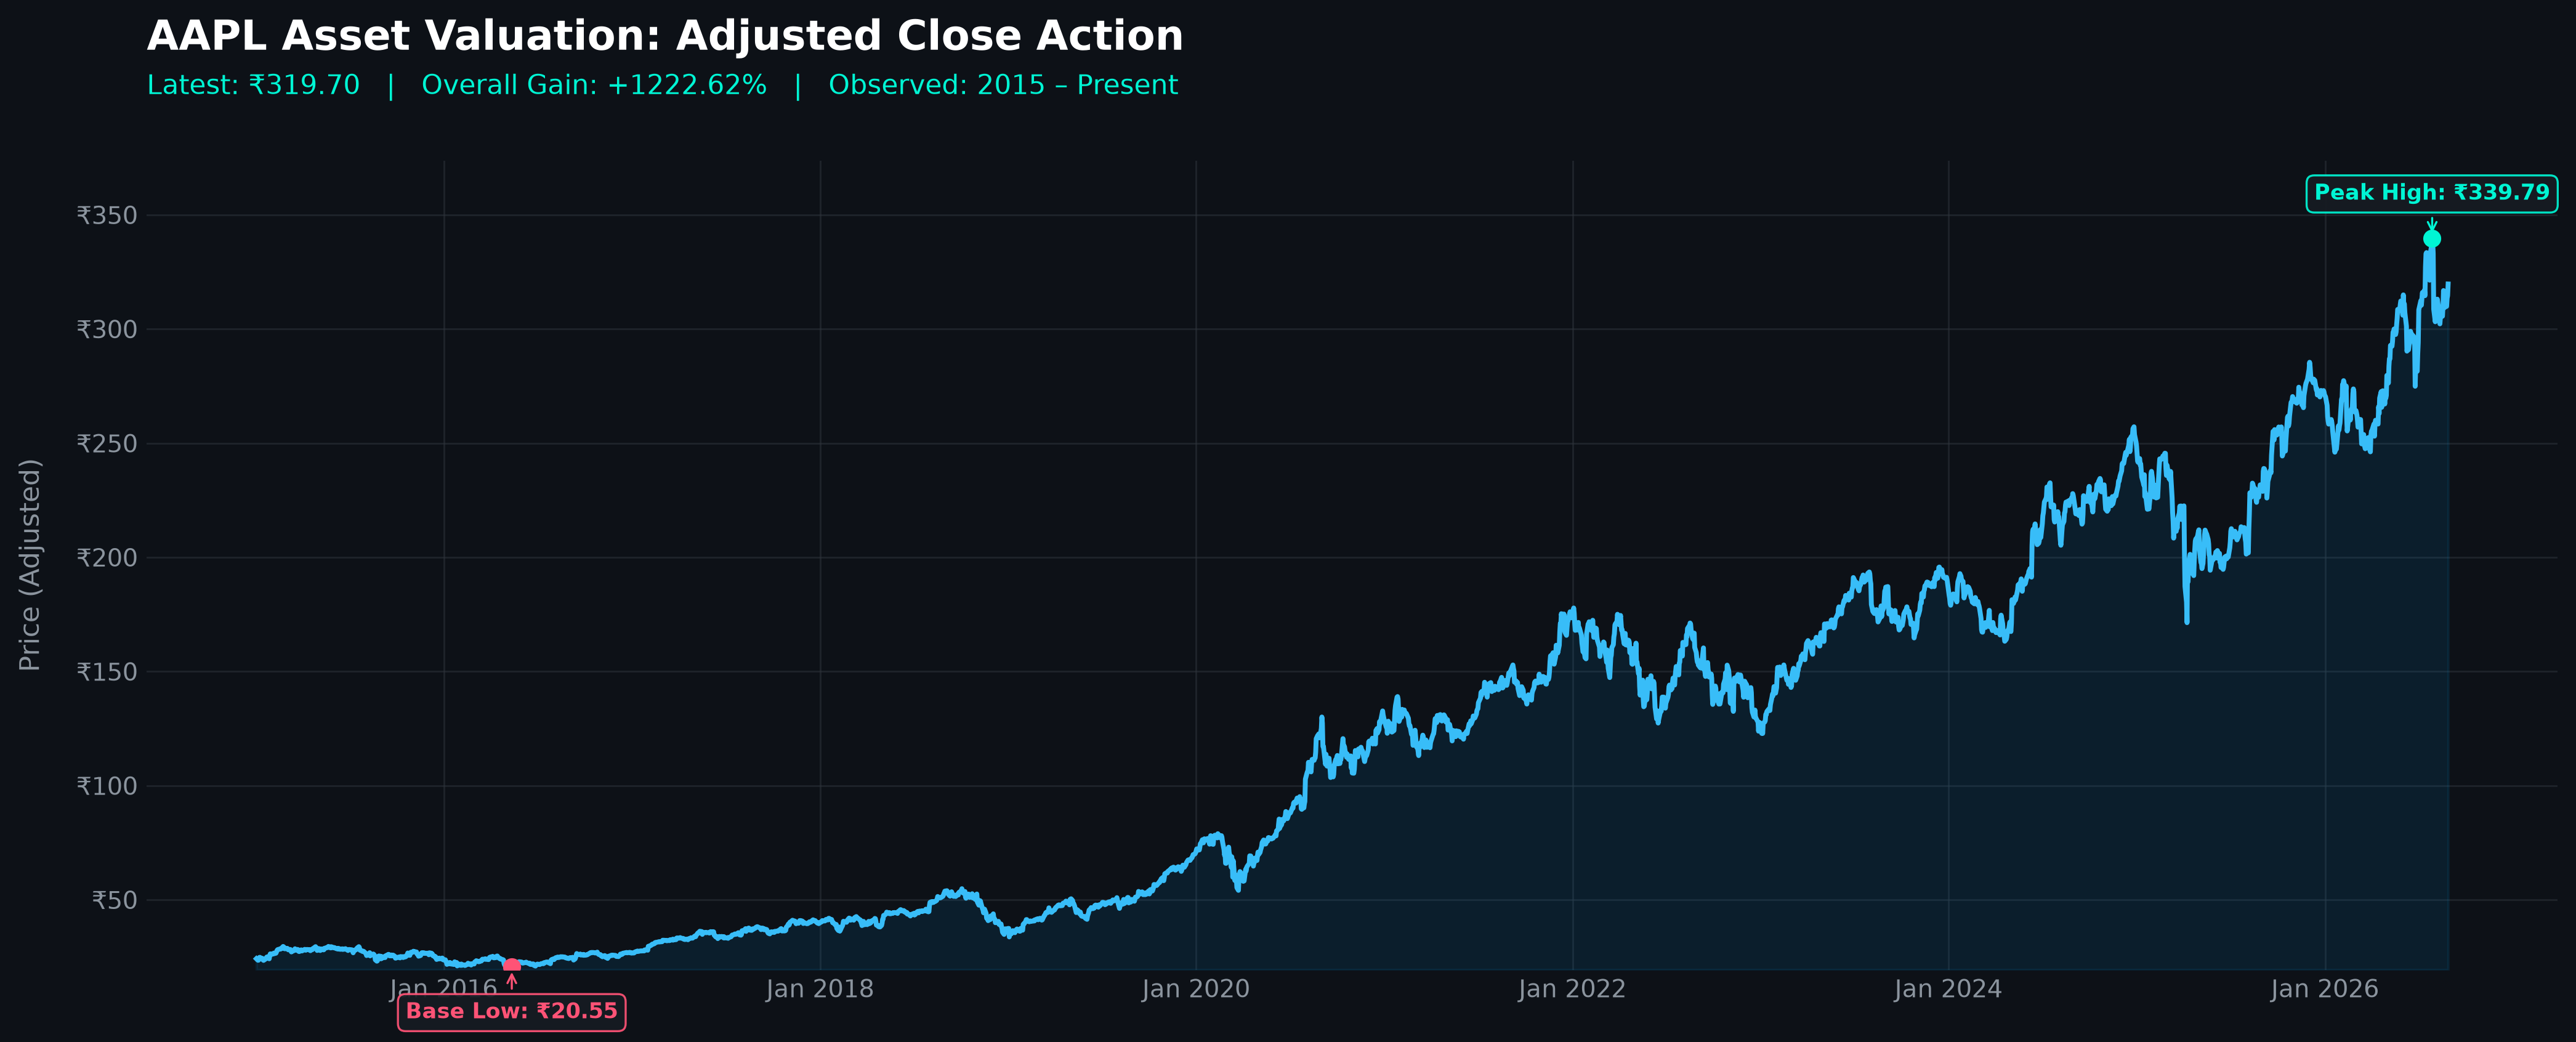

In [53]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

date_col = "date"
price_col = "Adj Close_AAPL"

features_df[date_col] = pd.to_datetime(features_df[date_col])

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(15, 6), dpi=300)
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

line_color = "#38BDF8"  
fill_color = "#0284C7"

ax.plot(
    features_df[date_col],
    features_df[price_col],
    color=line_color,
    linewidth=1.9,
    zorder=3,
    label="AAPL Adj Close",)

y_floor = features_df[price_col].min() * 0.94
ax.fill_between(
    features_df[date_col],
    features_df[price_col],
    y_floor,
    color=fill_color,
    alpha=0.12,
    zorder=2,)

max_idx = features_df[price_col].idxmax()
min_idx = features_df[price_col].idxmin()

max_date = features_df.loc[max_idx, date_col]
max_val = features_df.loc[max_idx, price_col]
min_date = features_df.loc[min_idx, date_col]
min_val = features_df.loc[min_idx, price_col]

ax.scatter([max_date], [max_val], color="#00F5D4", s=36, zorder=5)
ax.annotate(
    f"Peak High: ₹{max_val:,.2f}",
    xy=(max_date, max_val),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center",
    fontsize=8.5,
    fontweight="bold",
    color="#00F5D4",
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="#161B22",
        ec="#00F5D4",
        lw=0.8,
        alpha=0.92,
    ),
    arrowprops=dict(arrowstyle="->", color="#00F5D4", lw=0.8),
    zorder=6,)

ax.scatter([min_date], [min_val], color="#FF5376", s=36, zorder=5)
ax.annotate(
    f"Base Low: ₹{min_val:,.2f}",
    xy=(min_date, min_val),
    xytext=(0, -20),
    textcoords="offset points",
    ha="center",
    fontsize=8.5,
    fontweight="bold",
    color="#FF5376",
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="#161B22",
        ec="#FF5376",
        lw=0.8,
        alpha=0.92,
    ),
    arrowprops=dict(arrowstyle="->", color="#FF5376", lw=0.8),
    zorder=6,)

current_close = features_df[price_col].iloc[-1]
initial_close = features_df[price_col].iloc[0]
total_return = ((current_close - initial_close) / initial_close) * 100
return_color = "#00F5D4" if total_return >= 0 else "#FF5376"

fig.text(
    0.08,
    0.95,
    "AAPL Asset Valuation: Adjusted Close Action",
    fontsize=16,
    fontweight="bold",
    color="#FFFFFF",
    ha="left",)

fig.text(
    0.08,
    0.91,
    f"Latest: ₹{current_close:,.2f}   |   Overall Gain: {total_return:+.2f}%   |   Observed: 2015 – Present",
    fontsize=10.5,
    color=return_color,
    ha="left",)

ax.grid(
    True, which="major", color="#30363D", linestyle="-", linewidth=0.7, alpha=0.5)
ax.grid(
    True, which="minor", color="#21262D", linestyle=":", linewidth=0.5, alpha=0.3)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(
    axis="both", which="both", colors="#8B949E", labelsize=9.5, length=0)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("₹{x:,.0f}"))
ax.set_ylabel("Price (Adjusted)", color="#8B949E", fontsize=10.5, labelpad=12)

ax.set_ylim(y_floor, features_df[price_col].max() * 1.10)

plt.subplots_adjust(top=0.85, bottom=0.12, left=0.08, right=0.95)

EDA_DIR = Path("../results/eda")
EDA_DIR.mkdir(parents=True, exist_ok=True)

graph_path = EDA_DIR / "aapl_price_action.png"

plt.savefig(
    graph_path,
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",)

plt.show()

In [18]:
numeric_df = features_df.select_dtypes(include=np.number)

print("Numerical columns:", numeric_df.shape[1])

Numerical columns: 288


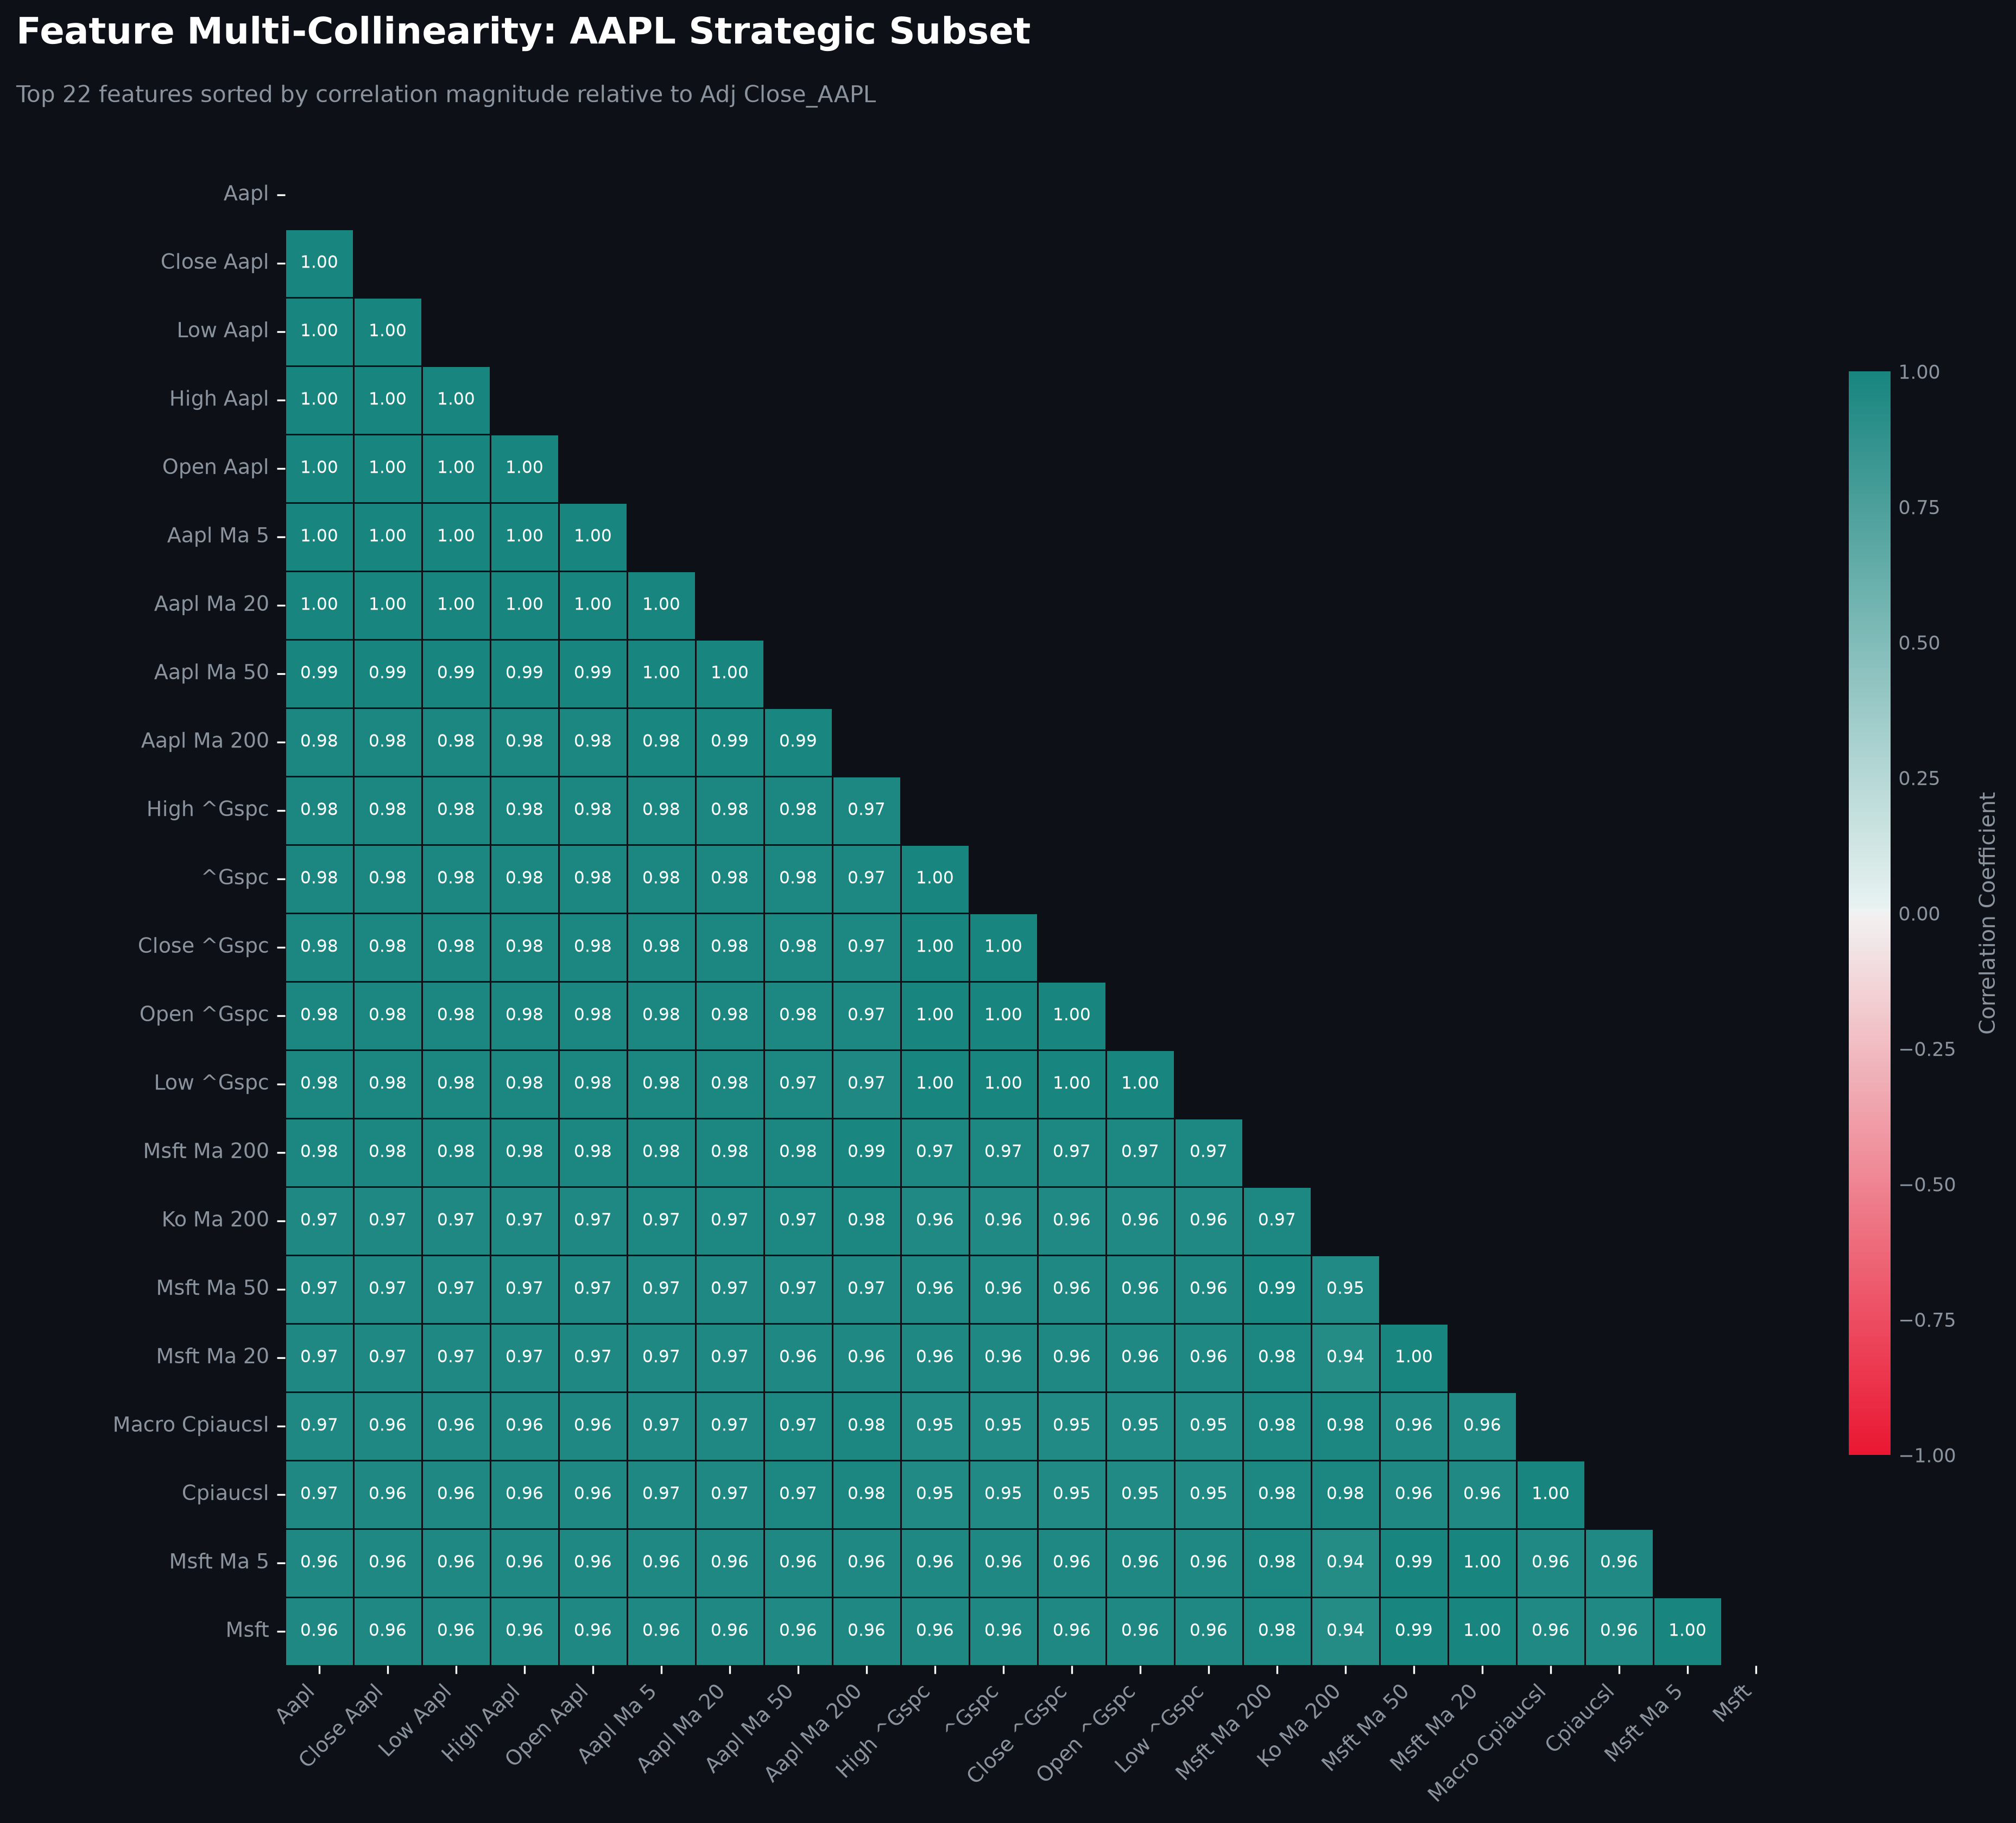

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

target_col = "Adj Close_AAPL"
corr_matrix = numeric_df.corr()

top_features = corr_matrix[target_col].abs().nlargest(22).index
corr_subset = corr_matrix.loc[top_features, top_features]

mask = np.triu(np.ones_like(corr_subset, dtype=bool))

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(15, 12), dpi=300)
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

cmap = sns.diverging_palette(10, 185, s=95, l=50, n=100, as_cmap=True)

sns.heatmap(
    corr_subset,
    mask=mask,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.6,
    linecolor="#0D1117",  
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7.5, "weight": "medium", "color": "#FFFFFF"},
    cbar_kws={
        "shrink": 0.72,
        "aspect": 26,
        "pad": 0.03,
        "label": "Pearson Correlation",
    },
    ax=ax,)

clean_labels = [
    c.replace("Features_", "")
    .replace("Adj Close_", "")
    .replace("_", " ")
    .title()
    for c in top_features]
ax.set_xticklabels(
    clean_labels, rotation=45, ha="right", fontsize=9, color="#8B949E")
ax.set_yticklabels(clean_labels, rotation=0, fontsize=9, color="#8B949E")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8.5, colors="#8B949E", length=0)
cbar.set_label("Correlation Coefficient", color="#8B949E", fontsize=9.5, labelpad=10)
cbar.outline.set_visible(False)

fig.text(
    0.08,
    0.95,
    "Feature Multi-Collinearity: AAPL Strategic Subset",
    fontsize=16,
    fontweight="bold",
    color="#FFFFFF",
    ha="left",)
fig.text(
    0.08,
    0.92,
    f"Top 22 features sorted by correlation magnitude relative to {target_col}",
    fontsize=10,
    color="#8B949E",
    ha="left",)

plt.subplots_adjust(top=0.89, bottom=0.12, left=0.15, right=0.95)

EDA_DIR = Path("../results/eda")
EDA_DIR.mkdir(parents=True, exist_ok=True)

graph_path = EDA_DIR / "aapl_feature_correlation.png"

plt.savefig(
    graph_path,
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",)

plt.show()

In [23]:
correlation_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False))

display(correlation_pairs.head(30))

Adj Close_^VIX   Features_vix_level    1.000000
                 Close_^VIX            1.000000
Close_^VIX       Features_vix_level    1.000000
Adj Close_^GSPC  Close_^GSPC           1.000000
Macro_CPIAUCSL   Features_CPIAUCSL     1.000000
Macro_UNRATE     Features_UNRATE       1.000000
Macro_DGS10      Features_DGS10        1.000000
Macro_DGS3MO     Features_DGS3MO       1.000000
Adj Close_NVDA   Close_NVDA            1.000000
Adj Close_AAPL   Close_AAPL            0.999961
High_^GSPC       Open_^GSPC            0.999896
Adj Close_^GSPC  Low_^GSPC             0.999881
Close_^GSPC      Low_^GSPC             0.999881
Close_MSFT       Low_MSFT              0.999879
                 High_MSFT             0.999874
Close_^GSPC      High_^GSPC            0.999873
Adj Close_^GSPC  High_^GSPC            0.999873
High_MSFT        Open_MSFT             0.999871
Adj Close_MSFT   Close_MSFT            0.999871
Low_MSFT         Open_MSFT             0.999870
High_NVDA        Open_NVDA             0

In [27]:
print([c for c in features_df.columns if 'target' in c.lower() or 'signal' in c.lower() or 'position' in c.lower() or 'label' in c.lower()])

[]


In [30]:
target_related_columns
print(features_df.columns.tolist())

['date', 'Adj Close_AAPL', 'Adj Close_CAT', 'Adj Close_HD', 'Adj Close_JNJ', 'Adj Close_JPM', 'Adj Close_KO', 'Adj Close_MSFT', 'Adj Close_NVDA', 'Adj Close_PG', 'Adj Close_XOM', 'Adj Close_^GSPC', 'Adj Close_^VIX', 'Close_AAPL', 'Close_CAT', 'Close_HD', 'Close_JNJ', 'Close_JPM', 'Close_KO', 'Close_MSFT', 'Close_NVDA', 'Close_PG', 'Close_XOM', 'Close_^GSPC', 'Close_^VIX', 'High_AAPL', 'High_CAT', 'High_HD', 'High_JNJ', 'High_JPM', 'High_KO', 'High_MSFT', 'High_NVDA', 'High_PG', 'High_XOM', 'High_^GSPC', 'High_^VIX', 'Low_AAPL', 'Low_CAT', 'Low_HD', 'Low_JNJ', 'Low_JPM', 'Low_KO', 'Low_MSFT', 'Low_NVDA', 'Low_PG', 'Low_XOM', 'Low_^GSPC', 'Low_^VIX', 'Open_AAPL', 'Open_CAT', 'Open_HD', 'Open_JNJ', 'Open_JPM', 'Open_KO', 'Open_MSFT', 'Open_NVDA', 'Open_PG', 'Open_XOM', 'Open_^GSPC', 'Open_^VIX', 'Volume_AAPL', 'Volume_CAT', 'Volume_HD', 'Volume_JNJ', 'Volume_JPM', 'Volume_KO', 'Volume_MSFT', 'Volume_NVDA', 'Volume_PG', 'Volume_XOM', 'Volume_^GSPC', 'Volume_^VIX', 'Macro_DGS10', 'Macro_DGS

In [31]:
for column in target_related_columns:
    print("\nColumn:", column)
    print("Data type:", features_df[column].dtype)
    print("Unique values:", features_df[column].nunique())
    print(features_df[column].value_counts(dropna=False).head(10))


Column: Adj Close_AAPL
Data type: float64
Unique values: 2898
Adj Close_AAPL
28.890949    2
28.217821    2
24.803474    2
23.957386    2
22.140324    2
25.852911    2
25.273079    2
26.477541    2
26.622356    2
27.583170    2
Name: count, dtype: int64

Column: Adj Close_CAT
Data type: float64
Unique values: 2900
Adj Close_CAT
60.459919    2
62.750713    2
64.383743    2
64.490463    2
67.211876    2
59.146648    2
58.546581    2
54.758881    2
55.988010    2
52.081097    2
Name: count, dtype: int64

Column: Adj Close_HD
Data type: float64
Unique values: 2891
Adj Close_HD
78.952576     2
85.195648     2
85.241219     2
86.389244     2
87.787437     2
88.979317     2
89.919113     2
102.508835    2
104.584839    2
105.042404    2
Name: count, dtype: int64

Column: Adj Close_JNJ
Data type: float64
Unique values: 2864
Adj Close_JNJ
113.765106    3
74.244667     2
73.217400     2
73.407120     2
73.370674     2
73.567581     2
73.339722     2
69.138458     2
76.213806     2
80.215515     

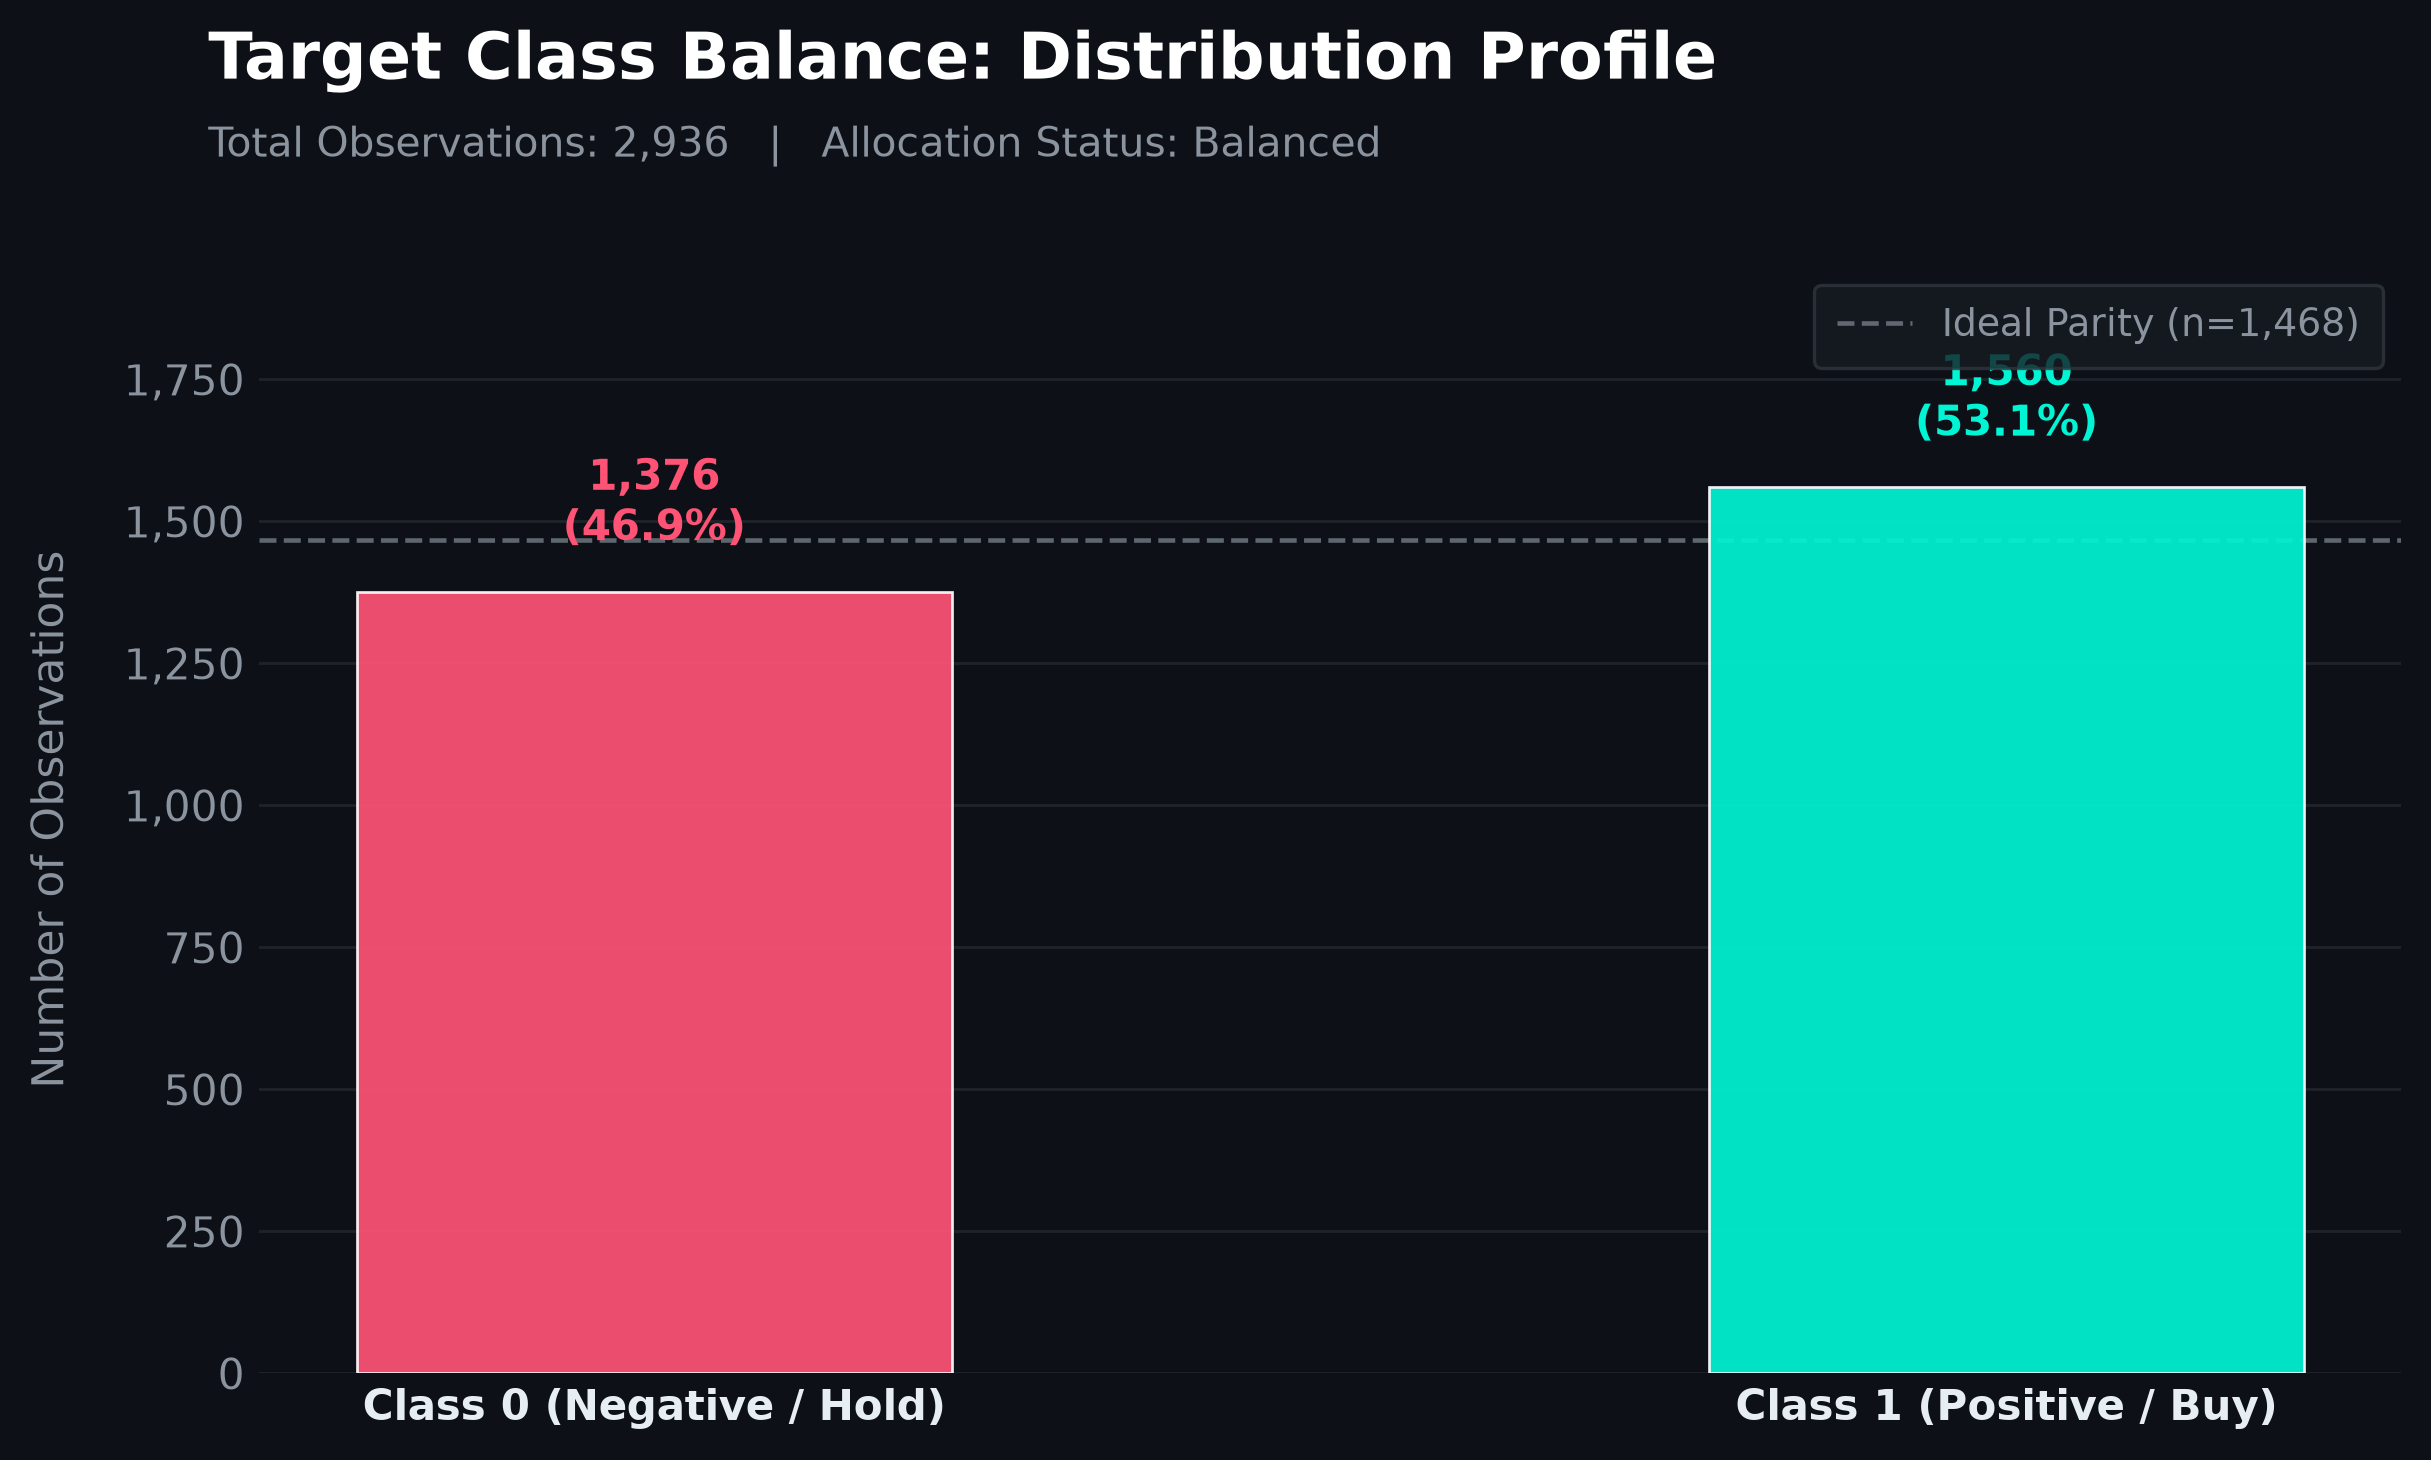

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.style.use("dark_background")

target_column = "target"

fig, ax = plt.subplots(figsize=(8.5, 5.2), dpi=300)
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

target_counts = features_df[target_column].dropna().value_counts().sort_index()
total_obs = len(features_df[target_column].dropna())
categories = [str(idx) for idx in target_counts.index]
counts = target_counts.values
percentages = (counts / total_obs) * 100

palette = ["#FF5376", "#00F5D4", "#38BDF8", "#F59E0B"]
bar_colors = [palette[i % len(palette)] for i in range(len(counts))]

bars = ax.bar(
    categories,
    counts,
    width=0.44,
    color=bar_colors,
    edgecolor="#FFFFFF",
    linewidth=0.65,
    alpha=0.92,
    zorder=3,
)

for bar, count, pct, col in zip(bars, counts, percentages, bar_colors):
    y_pos = bar.get_height()
    ax.annotate(
        f"{count:,}\n({pct:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, y_pos),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=col,
        zorder=4,
    )

balanced_level = total_obs / len(counts)
ax.axhline(
    balanced_level,
    color="#8B949E",
    linestyle="--",
    linewidth=1.1,
    alpha=0.65,
    label=f"Ideal Parity (n={int(balanced_level):,})",
    zorder=2,
)

imbalance_ratio = max(counts) / min(counts) if min(counts) > 0 else 0
ratio_status = "Balanced" if imbalance_ratio < 1.25 else f"Skewed ({imbalance_ratio:.2f}:1)"

fig.text(
    0.08,
    0.95,
    "Target Class Balance: Distribution Profile",
    fontsize=15.5,
    fontweight="bold",
    color="#FFFFFF",
    ha="left",
)
fig.text(
    0.08,
    0.90,
    f"Total Observations: {total_obs:,}   |   Allocation Status: {ratio_status}",
    fontsize=9.8,
    color="#8B949E",
    ha="left",)

label_map = {"0": "Class 0 (Negative / Hold)", "1": "Class 1 (Positive / Buy)"}
formatted_x = [label_map.get(c, f"Class {c}") for c in categories]

ax.grid(True, which="major", axis="y", color="#30363D", linestyle="-", linewidth=0.7, alpha=0.5)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="both", which="both", colors="#8B949E", labelsize=10, length=0)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("Number of Observations", color="#8B949E", fontsize=10.5, labelpad=12)

ax.set_xticks(range(len(categories)))
ax.set_xticklabels(formatted_x, color="#E6EDF3", fontweight="semibold", fontsize=10)
ax.set_ylim(0, max(counts) * 1.25)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="#161B22",
    edgecolor="#30363D",
    fontsize=9,
    labelcolor="#8B949E",
    borderpad=0.6,
)
legend.get_frame().set_linewidth(0.8)

plt.subplots_adjust(top=0.83, bottom=0.12, left=0.10, right=0.94)
plt.show()

In [36]:
from IPython.display import HTML, display
import pandas as pd

target_column = "target"

# 1. Compute Metrics
counts = features_df[target_column].value_counts().sort_index()
total = len(features_df[target_column].dropna())
percentages = (counts / total) * 100

class_labels = {
    0: "Class 0 (Negative / Neutral)",
    1: "Class 1 (Positive / Long)"
}

# 2. Build Modern Obsidian HTML Card
rows_html = ""
for idx in counts.index:
    c = counts[idx]
    pct = percentages[idx]
    label = class_labels.get(idx, f"Class {idx}")
    accent_color = "#00F5D4" if idx == 1 else "#FF5376"

    rows_html += f"""
    <tr style="border-bottom: 1px solid #21262D;">
        <td style="padding: 14px 18px; font-weight: 500; color: #E6EDF3;">{label}</td>
        <td style="padding: 14px 18px; text-align: right; color: #C9D1D9; font-variant-numeric: tabular-nums;">{c:,}</td>
        <td style="padding: 14px 18px; text-align: right; font-weight: 600; color: {accent_color}; font-variant-numeric: tabular-nums;">{pct:.2f}%</td>
        <td style="padding: 14px 18px; width: 140px;">
            <div style="background: #21262D; border-radius: 4px; height: 8px; overflow: hidden;">
                <div style="background: {accent_color}; width: {pct:.1f}%; height: 100%; border-radius: 4px;"></div>
            </div>
        </td>
    </tr>
    """

html_card = f"""
<div style="background-color: #0D1117; border: 1px solid #30363D; border-radius: 10px; padding: 20px; max-width: 620px; margin: 12px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;">
    <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 14px; border-bottom: 1px solid #21262D; padding-bottom: 10px;">
        <span style="font-size: 14px; font-weight: 700; color: #FFFFFF; letter-spacing: 0.03em;">TARGET CLASS DISTRIBUTION</span>
        <span style="font-size: 11px; color: #8B949E;">N = {total:,} observations</span>
    </div>
    <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
        <thead>
            <tr style="border-bottom: 1px solid #30363D;">
                <th style="padding: 8px 18px; text-align: left; color: #8B949E; font-size: 11px; text-transform: uppercase;">Class Target</th>
                <th style="padding: 8px 18px; text-align: right; color: #8B949E; font-size: 11px; text-transform: uppercase;">Count</th>
                <th style="padding: 8px 18px; text-align: right; color: #8B949E; font-size: 11px; text-transform: uppercase;">Share</th>
                <th style="padding: 8px 18px; text-align: left; color: #8B949E; font-size: 11px; text-transform: uppercase;">Distribution</th>
            </tr>
        </thead>
        <tbody>
            {rows_html}
        </tbody>
    </table>
</div>
"""

display(HTML(html_card))

Class Target,Count,Share,Distribution
Class 0 (Negative / Neutral),"1,376",46.87%,
Class 1 (Positive / Long),"1,560",53.13%,


In [55]:
from IPython.display import HTML, display
import pandas as pd

missing_count = features_df.isnull().sum()
missing_pct = (features_df.isnull().mean() * 100).round(2)

missing_report = (
    pd.DataFrame({
        "missing_count": missing_count,
        "missing_percentage": missing_pct
    })
    .query("missing_count > 0")
    .sort_values("missing_percentage", ascending=False))

total_rows = len(features_df)
total_missing_cols = len(missing_report)

if total_missing_cols == 0:
    display(HTML("""
    <div style="background-color: #0D1117; border: 1px solid #238636; border-radius: 8px; padding: 16px 20px; max-width: 650px; font-family: Inter, sans-serif; color: #3FB950; font-weight: 600;">
        ✔ Zero Missing Values Detected across all features!
    </div>
    """))
else:
    top_30 = missing_report.head(30)
    rows_html = ""

    for idx, (col_name, row) in enumerate(top_30.iterrows()):
        count = int(row["missing_count"])
        pct = row["missing_percentage"]
        
        if pct > 50:
            bar_color = "#FF5376"
            badge_bg = "rgba(255, 83, 118, 0.15)"
            badge_color = "#FF5376"
        elif pct > 20:
            bar_color = "#F59E0B"
            badge_bg = "rgba(245, 158, 11, 0.15)"
            badge_color = "#F59E0B"
        else:
            bar_color = "#00F5D4"
            badge_bg = "rgba(0, 245, 212, 0.15)"
            badge_color = "#00F5D4"

        clean_name = col_name.replace("Features_", "").replace("Adj Close_", "")

        rows_html += f"""
        <tr style="border-bottom: 1px solid #21262D; transition: background 0.2s;" onmouseover="this.style.background='#161B22'" onmouseout="this.style.background='transparent'">
            <td style="padding: 10px 14px; color: #8B949E; font-size: 11px; width: 30px;">#{idx+1}</td>
            <td style="padding: 10px 14px; font-family: monospace; font-size: 12px; color: #E6EDF3; font-weight: 500;">{clean_name}</td>
            <td style="padding: 10px 14px; text-align: right; color: #C9D1D9; font-variant-numeric: tabular-nums;">{count:,}</td>
            <td style="padding: 10px 14px; text-align: right;">
                <span style="background: {badge_bg}; color: {badge_color}; padding: 3px 7px; border-radius: 4px; font-weight: 600; font-size: 11.5px; font-variant-numeric: tabular-nums;">
                    {pct:.2f}%
                </span>
            </td>
            <td style="padding: 10px 14px; width: 140px;">
                <div style="background: #21262D; border-radius: 4px; height: 7px; overflow: hidden;">
                    <div style="background: {bar_color}; width: {min(pct, 100):.1f}%; height: 100%; border-radius: 4px;"></div>
                </div>
            </td>
        </tr>
        """

    html_widget = f"""
    <div style="background-color: #0D1117; border: 1px solid #30363D; border-radius: 10px; padding: 22px; max-width: 820px; margin: 12px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
        <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 16px; border-bottom: 1px solid #21262D; padding-bottom: 12px;">
            <div>
                <span style="font-size: 14.5px; font-weight: 700; color: #FFFFFF; letter-spacing: 0.04em;">DATA INTEGRITY AUDIT: NULL VALUES</span>
                <span style="margin-left: 10px; font-size: 11px; background: #21262D; color: #8B949E; padding: 3px 8px; border-radius: 12px; border: 1px solid #30363D;">Top 30 Deficits</span>
            </div>
            <span style="font-size: 11px; color: #8B949E;">Dataset Rows: {total_rows:,} | Defective Features: <b style="color: #FF5376;">{total_missing_cols}</b></span>
        </div>
        <div style="max-height: 480px; overflow-y: auto; padding-right: 4px;">
            <table style="width: 100%; border-collapse: collapse; font-size: 12.5px;">
                <thead style="position: sticky; top: 0; background-color: #0D1117; z-index: 2;">
                    <tr style="border-bottom: 1px solid #30363D;">
                        <th style="padding: 8px 14px; text-align: left; color: #8B949E; font-size: 10.5px; text-transform: uppercase;">#</th>
                        <th style="padding: 8px 14px; text-align: left; color: #8B949E; font-size: 10.5px; text-transform: uppercase;">Feature Column</th>
                        <th style="padding: 8px 14px; text-align: right; color: #8B949E; font-size: 10.5px; text-transform: uppercase;">Null Count</th>
                        <th style="padding: 8px 14px; text-align: right; color: #8B949E; font-size: 10.5px; text-transform: uppercase;">Deficit (%)</th>
                        <th style="padding: 8px 14px; text-align: left; color: #8B949E; font-size: 10.5px; text-transform: uppercase; width: 140px;">Integrity Bar</th>
                    </tr>
                </thead>
                <tbody>
                    {rows_html}
                </tbody>
            </table>
        </div>
    </div>
    """

    display(HTML(html_widget))

EDA_DIR = Path("../results/eda")
EDA_DIR.mkdir(parents=True, exist_ok=True)

graph_path = EDA_DIR / "Data_Integrity_Audit.png"

plt.savefig(
    graph_path,
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",)     

#,Feature Column,Null Count,Deficit (%),Integrity Bar
#1,JPM_ma_200,199,6.79%,
#2,AAPL_ma_200,199,6.79%,
#3,MSFT_ma_200,199,6.79%,
#4,JNJ_price_to_ma200,199,6.79%,
#5,PG_price_to_ma200,199,6.79%,
#6,CAT_price_to_ma200,199,6.79%,
#7,KO_price_to_ma200,199,6.79%,
#8,NVDA_price_to_ma200,199,6.79%,
#9,KO_ma_200,199,6.79%,
#10,CAT_ma_200,199,6.79%,


<Figure size 640x480 with 0 Axes>

In [39]:
numeric_columns = features_df.select_dtypes(
    include=np.number
).columns.tolist()

print("Total numerical columns:", len(numeric_columns))

Total numerical columns: 289


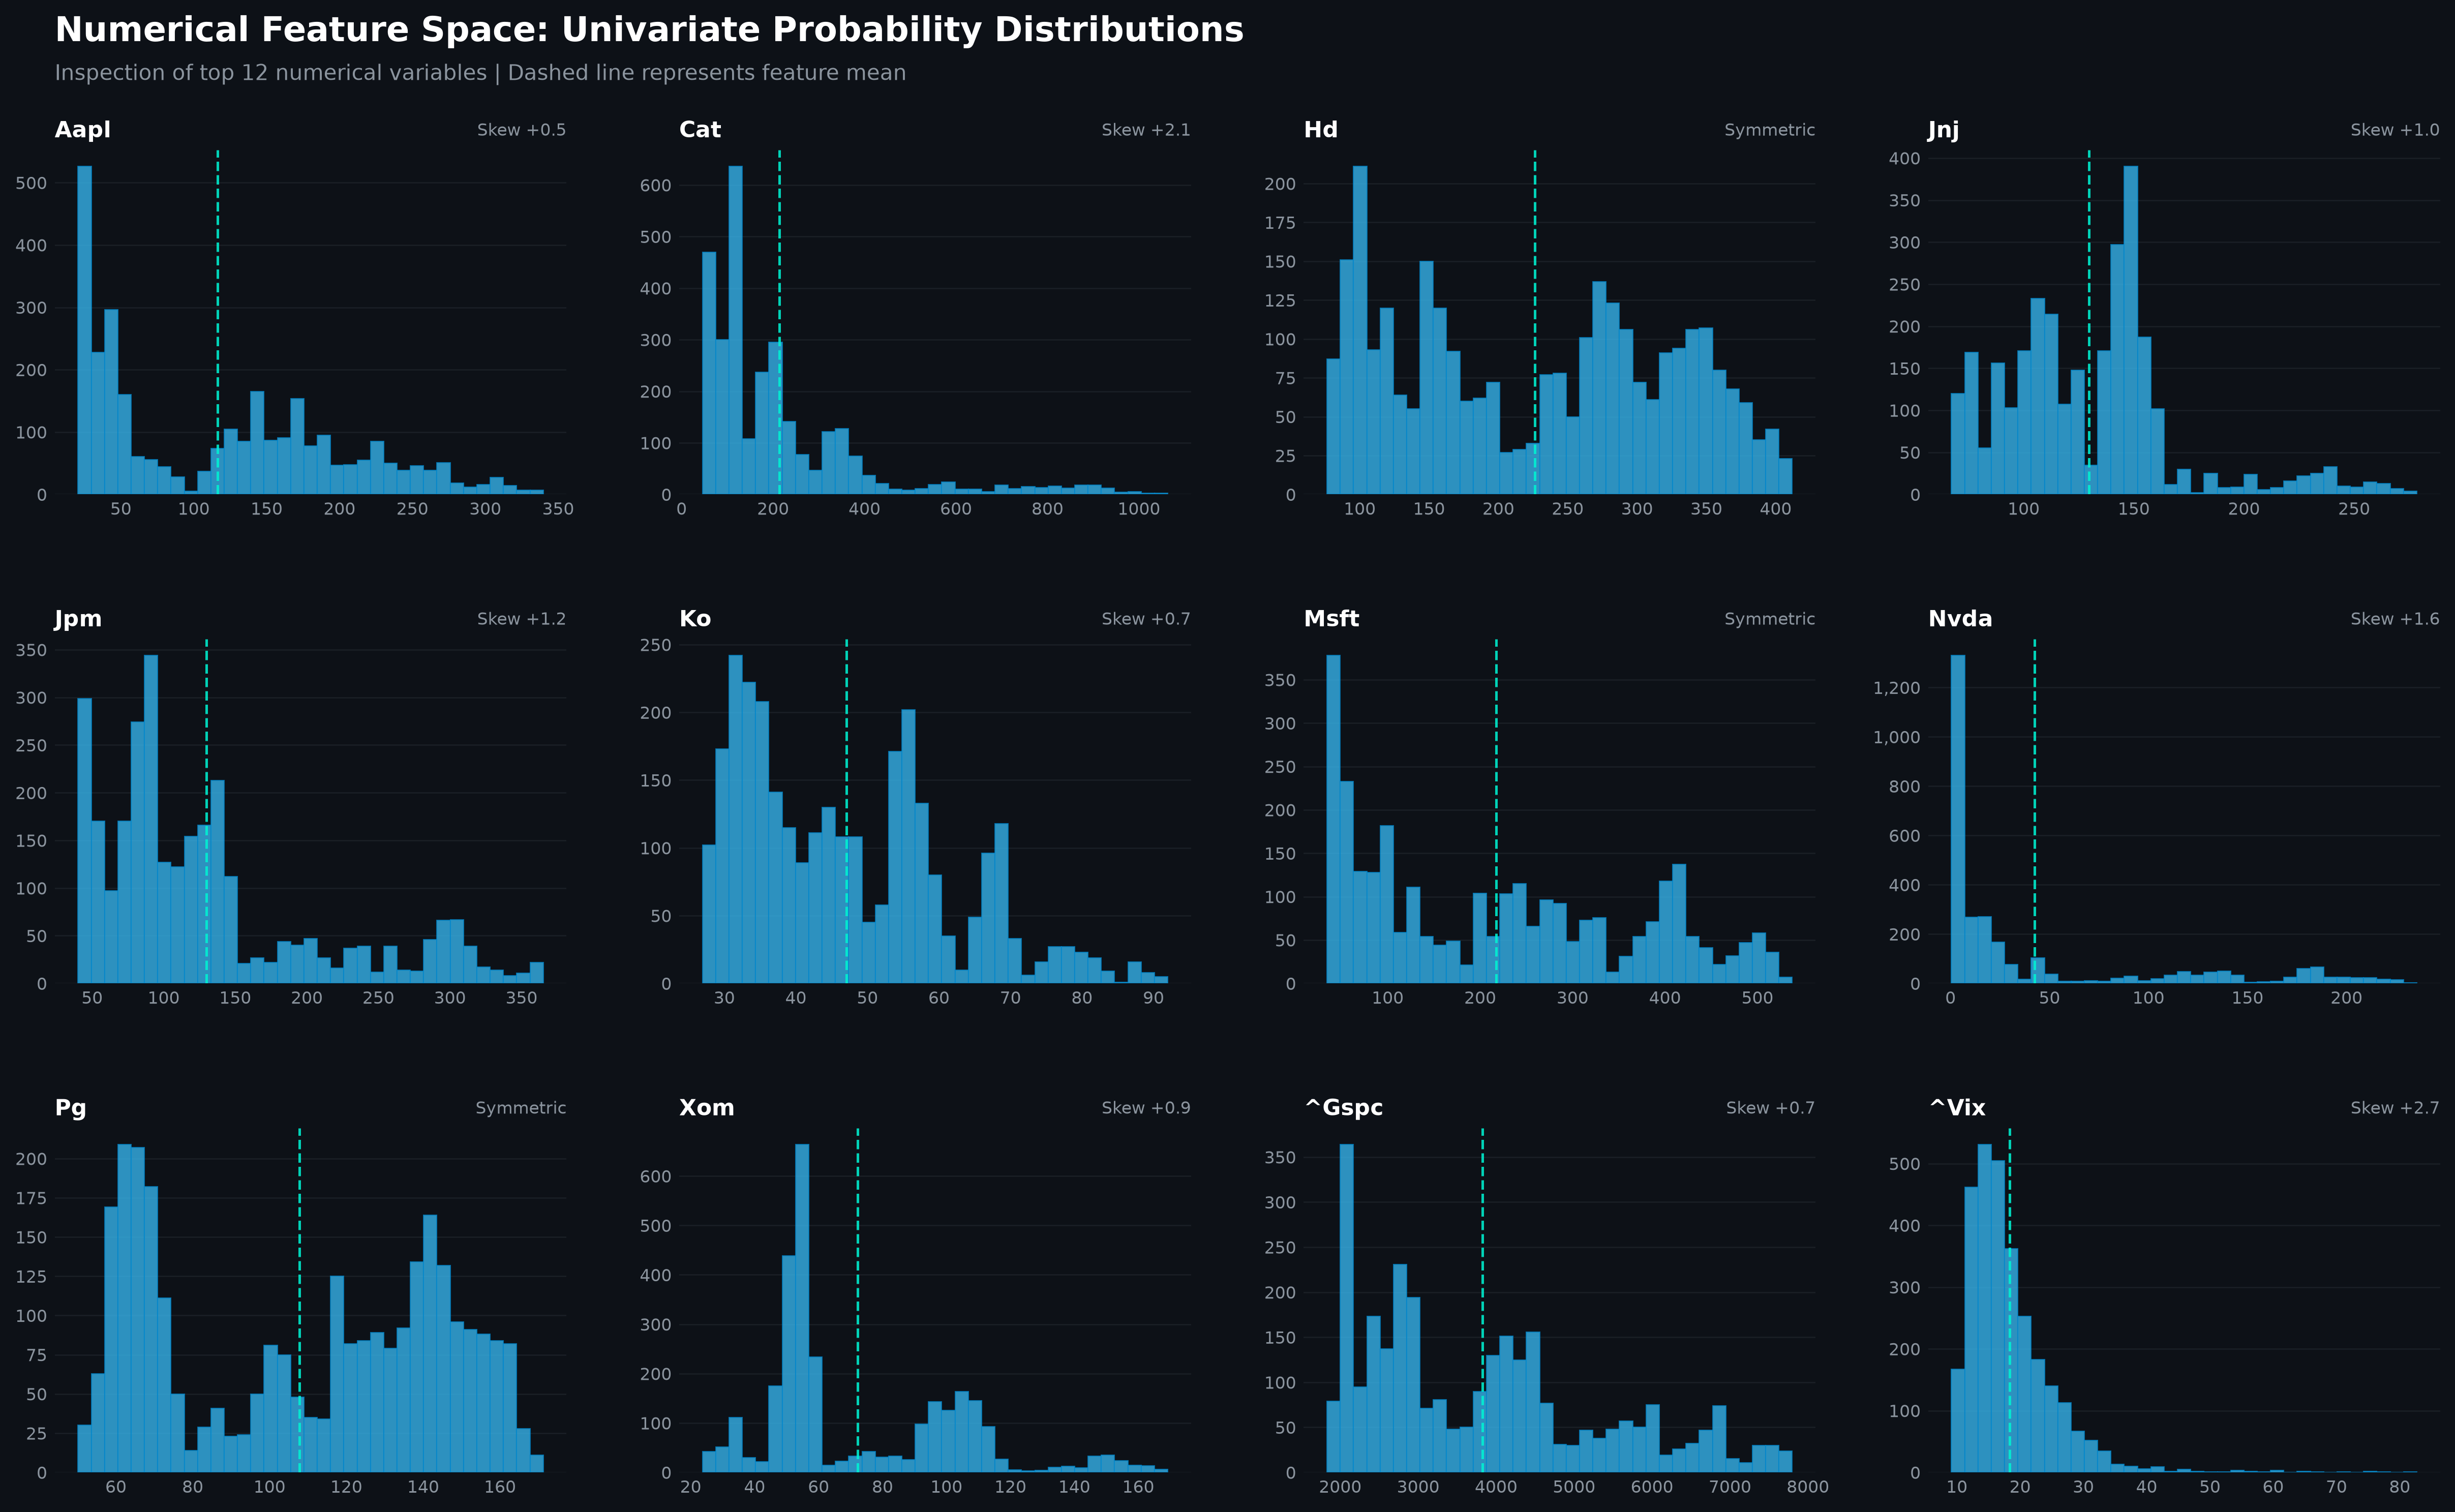

In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.style.use("dark_background")

selected_columns = list(numeric_columns[:12])
num_plots = len(selected_columns)
cols_per_row = 4
rows_needed = math.ceil(num_plots / cols_per_row)

fig, axes = plt.subplots(
    rows_needed,
    cols_per_row,
    figsize=(17, rows_needed * 3.4),
    dpi=300,
    facecolor="#0D1117",)
axes = np.array(axes).flatten()

bar_color = "#38BDF8"      
mean_color = "#00F5D4"     
border_color = "#0284C7"

for i, col in enumerate(selected_columns):
    ax = axes[i]
    ax.set_facecolor("#0D1117")

    series = features_df[col].dropna()

    clean_title = (
        col.replace("Features_", "")
        .replace("Adj Close_", "")
        .replace("_", " ")
        .title())
    mean_val = series.mean()
    skew_val = series.skew()

    n, bins, patches = ax.hist(
        series,
        bins=35,
        color=bar_color,
        edgecolor=border_color,
        linewidth=0.5,
        alpha=0.75,
        zorder=2,)

    ax.axvline(
        mean_val,
        color=mean_color,
        linestyle="--",
        linewidth=1.2,
        alpha=0.85,
        label="Mean",
        zorder=3,)

    skew_status = "Symmetric" if abs(skew_val) < 0.5 else f"Skew {skew_val:+.1f}"
    ax.set_title(
        f"{clean_title}",
        fontsize=10.5,
        fontweight="bold",
        color="#FFFFFF",
        loc="left",
        pad=6,)

    ax.text(
        1.0,
        1.03,
        skew_status,
        transform=ax.transAxes,
        fontsize=8,
        color="#8B949E",
        ha="right",
        va="bottom",)

    ax.grid(
        True,
        which="major",
        axis="y",
        color="#30363D",
        linestyle="-",
        linewidth=0.6,
        alpha=0.4,)
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(
        axis="both", which="both", colors="#8B949E", labelsize=8, length=0)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

fig.text(
    0.05,
    0.98,
    "Numerical Feature Space: Univariate Probability Distributions",
    fontsize=16,
    fontweight="bold",
    color="#FFFFFF",
    ha="left",)
fig.text(
    0.05,
    0.955,
    f"Inspection of top {num_plots} numerical variables | Dashed line represents feature mean",
    fontsize=10,
    color="#8B949E",
    ha="left",)

plt.subplots_adjust(
    top=0.91,
    bottom=0.06,
    left=0.05,
    right=0.97,
    hspace=0.42,
    wspace=0.22,)

    EDA_DIR = Path("../results/eda")
EDA_DIR.mkdir(parents=True, exist_ok=True)

graph_path = EDA_DIR / "aapl_univariate_distributions.png"

plt.savefig(
    graph_path,
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",)

plt.show()

In [56]:
from IPython.display import HTML, display
import pandas as pd

outlier_summary = []

for column in numeric_columns:
    series = features_df[column].dropna()

    if series.empty:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()

    outlier_summary.append({
        "feature": column,
        "outlier_count": int(outlier_count),
        "outlier_percentage": round(outlier_count / len(series) * 100, 2),})

outlier_report = pd.DataFrame(outlier_summary)
outlier_report = outlier_report.sort_values("outlier_percentage", ascending=False)

# 2. Build High-End Obsidian Outlier Dashboard Table
top_25 = outlier_report.head(25)
total_features = len(outlier_report)
contaminated_features = (outlier_report["outlier_count"] > 0).sum()

rows_html = ""
for idx, (_, row) in enumerate(top_25.iterrows()):
    pct = row["outlier_percentage"]
    count = int(row["outlier_count"])
    col_name = (
        str(row["feature"])
        .replace("Features_", "")
        .replace("Adj Close_", "")
        .replace("_", " "))

    if pct >= 15:
        bar_color = "#FF5376"  # Coral Red
        badge_bg = "rgba(255, 83, 118, 0.15)"
        badge_color = "#FF5376"
    elif pct >= 5:
        bar_color = "#F59E0B"  # Amber Gold
        badge_bg = "rgba(245, 158, 11, 0.15)"
        badge_color = "#F59E0B"
    else:
        bar_color = "#00F5D4"  # Neon Cyan
        badge_bg = "rgba(0, 245, 212, 0.15)"
        badge_color = "#00F5D4"

    rows_html += f"""
    <tr style="border-bottom: 1px solid #21262D; transition: background 0.2s;" onmouseover="this.style.background='#161B22'" onmouseout="this.style.background='transparent'">
        <td style="padding: 10px 14px; color: #8B949E; font-size: 11px; width: 32px;">#{idx+1}</td>
        <td style="padding: 10px 14px; font-family: 'JetBrains Mono', Consolas, monospace; font-size: 12px; color: #E6EDF3; font-weight: 500;">{col_name}</td>
        <td style="padding: 10px 14px; text-align: right; color: #C9D1D9; font-variant-numeric: tabular-nums;">{count:,}</td>
        <td style="padding: 10px 14px; text-align: right;">
            <span style="background: {badge_bg}; color: {badge_color}; padding: 3px 8px; border-radius: 4px; font-weight: 600; font-size: 11.5px; font-variant-numeric: tabular-nums;">
                {pct:.2f}%
            </span>
        </td>
        <td style="padding: 10px 14px; width: 140px;">
            <div style="background: #21262D; border-radius: 4px; height: 7px; overflow: hidden;">
                <div style="background: {bar_color}; width: {min(pct * 2, 100):.1f}%; height: 100%; border-radius: 4px;"></div>
            </div>
        </td>
    </tr>
    """

html_dashboard = f"""
<div style="background-color: #0D1117; border: 1px solid #30363D; border-radius: 10px; padding: 22px; max-width: 820px; margin: 12px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
    <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 16px; border-bottom: 1px solid #21262D; padding-bottom: 12px;">
        <div>
            <span style="font-size: 14.5px; font-weight: 700; color: #FFFFFF; letter-spacing: 0.04em;">IQR ANOMALY AUDIT: OUTLIER REPORT</span>
            <span style="margin-left: 10px; font-size: 11px; background: #21262D; color: #8B949E; padding: 3px 8px; border-radius: 12px; border: 1px solid #30363D;">Top 25 Skewed</span>
        </div>
        <span style="font-size: 11px; color: #8B949E;">Scanned Features: {total_features} | Impacted: <b style="color: #FF5376;">{contaminated_features}</b></span>
    </div>
    <div style="max-height: 480px; overflow-y: auto; padding-right: 4px;">
        <table style="width: 100%; border-collapse: collapse; font-size: 12.5px;">
            <thead style="position: sticky; top: 0; background-color: #0D1117; z-index: 2;">
                <tr style="border-bottom: 1px solid #30363D;">
                    <th style="padding: 8px 14px; text-align: left; color: #8B949E; font-size: 10.5px; text-transform: uppercase;">#</th>
                    <th style="padding: 8px 14px; text-align: left; color: #8B949E; font-size: 10.5px; text-transform: uppercase;">Feature</th>
                    <th style="padding: 8px 14px; text-align: right; color: #8B949E; font-size: 10.5px; text-transform: uppercase;">Outlier Count</th>
                    <th style="padding: 8px 14px; text-align: right; color: #8B949E; font-size: 10.5px; text-transform: uppercase;">Contamination (%)</th>
                    <th style="padding: 8px 14px; text-align: left; color: #8B949E; font-size: 10.5px; text-transform: uppercase; width: 140px;">Severity Bar</th>
                </tr>
            </thead>
            <tbody>
                {rows_html}
            </tbody>
        </table>
    </div>
</div>
"""

display(HTML(html_dashboard))

EDA_DIR = Path("../results/eda")
EDA_DIR.mkdir(parents=True, exist_ok=True)

graph_path = EDA_DIR / "IQR_Anomaly_Audit.png"

plt.savefig(
    graph_path,
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",)

#,Feature,Outlier Count,Contamination (%),Severity Bar
#1,unemployment change,756,26.45%,
#2,NVDA ma 20,550,18.89%,
#3,NVDA ma 50,542,18.81%,
#4,High NVDA,547,18.66%,
#5,NVDA ma 5,543,18.55%,
#6,Close NVDA,543,18.53%,
#7,NVDA,543,18.53%,
#8,Open NVDA,538,18.36%,
#9,Low NVDA,534,18.22%,
#10,NVDA ma 200,493,18.05%,


<Figure size 640x480 with 0 Axes>

In [43]:
# Target distribution

print("Target-related columns:")
print(target_related_columns)

Target-related columns:
['Adj Close_AAPL', 'Adj Close_CAT', 'Adj Close_HD', 'Adj Close_JNJ', 'Adj Close_JPM', 'Adj Close_KO', 'Adj Close_MSFT', 'Adj Close_NVDA', 'Adj Close_PG', 'Adj Close_XOM', 'Adj Close_^GSPC', 'Adj Close_^VIX', 'Close_AAPL', 'Close_CAT', 'Close_HD', 'Close_JNJ', 'Close_JPM', 'Close_KO', 'Close_MSFT', 'Close_NVDA', 'Close_PG', 'Close_XOM', 'Close_^GSPC', 'Close_^VIX', 'Features_AAPL_return_1d', 'Features_AAPL_return_5d', 'Features_AAPL_return_20d', 'Features_AAPL_return_60d', 'Features_MSFT_return_1d', 'Features_MSFT_return_5d', 'Features_MSFT_return_20d', 'Features_MSFT_return_60d', 'Features_JPM_return_1d', 'Features_JPM_return_5d', 'Features_JPM_return_20d', 'Features_JPM_return_60d', 'Features_XOM_return_1d', 'Features_XOM_return_5d', 'Features_XOM_return_20d', 'Features_XOM_return_60d', 'Features_JNJ_return_1d', 'Features_JNJ_return_5d', 'Features_JNJ_return_20d', 'Features_JNJ_return_60d', 'Features_PG_return_1d', 'Features_PG_return_5d', 'Features_PG_return_2

In [45]:
aapl_columns = [
    column
    for column in features_df.columns
    if "AAPL" in column
]

aapl_columns

['Adj Close_AAPL',
 'Close_AAPL',
 'High_AAPL',
 'Low_AAPL',
 'Open_AAPL',
 'Volume_AAPL',
 'Features_AAPL_return_1d',
 'Features_AAPL_return_5d',
 'Features_AAPL_return_20d',
 'Features_AAPL_return_60d',
 'Features_AAPL_log_return',
 'Features_AAPL_ma_5',
 'Features_AAPL_ma_20',
 'Features_AAPL_ma_50',
 'Features_AAPL_ma_200',
 'Features_AAPL_price_to_ma20',
 'Features_AAPL_price_to_ma50',
 'Features_AAPL_price_to_ma200',
 'Features_AAPL_volatility_5d',
 'Features_AAPL_volatility_20d',
 'Features_AAPL_volatility_60d',
 'Features_AAPL_intraday_range',
 'Features_AAPL_volume_change',
 'Features_AAPL_volume_ma20',
 'Features_AAPL_volume_ratio']

In [46]:
display(
    features_df[
        [
            "date",
            "Close_AAPL",
            "Features_AAPL_return_1d",
            "Features_AAPL_return_5d",
            "Features_AAPL_return_20d",
            "Features_AAPL_log_return"
        ]
    ].head(10)
)

,date,Close_AAPL,Features_AAPL_return_1d,Features_AAPL_return_5d,Features_AAPL_return_20d,Features_AAPL_log_return
0,2015-01-02,27.332500,NaN,NaN,NaN,NaN
1,2015-01-05,26.562500,-0.028171,NaN,NaN,-0.028576
2,2015-01-06,26.565001,0.000094,NaN,NaN,0.000094
3,2015-01-07,26.937500,0.014022,NaN,NaN,0.013924
4,2015-01-08,27.972500,0.038423,NaN,NaN,0.037703
5,2015-01-09,28.002501,0.001072,0.024513,NaN,0.001071
6,2015-01-12,27.312500,-0.024641,0.028235,NaN,-0.024949
7,2015-01-13,27.555000,0.008879,0.037266,NaN,0.008839
8,2015-01-14,27.450001,-0.003810,0.019026,NaN,-0.003818
9,2015-01-15,26.705000,-0.027140,-0.045312,NaN,-0.027515


In [47]:
# Future 5-day return

features_df["future_return_5d"] = (
    features_df["Close_AAPL"].shift(-5)
    / features_df["Close_AAPL"]
    - 1
)

display(
    features_df[
        ["date", "Close_AAPL", "future_return_5d"]
    ].head(10)
)

,date,Close_AAPL,future_return_5d
0,2015-01-02,27.332500,0.024513
1,2015-01-05,26.562500,0.028235
2,2015-01-06,26.565001,0.037267
3,2015-01-07,26.937500,0.019026
4,2015-01-08,27.972500,-0.045312
5,2015-01-09,28.002501,-0.053745
6,2015-01-12,27.312500,-0.004851
7,2015-01-13,27.555000,-0.006079
8,2015-01-14,27.450001,0.023679
9,2015-01-15,26.705000,0.057667


In [48]:
# Binary classification target

features_df["target"] = (
    features_df["future_return_5d"] > 0
).astype(int)

display(
    features_df[
        ["date", "Close_AAPL", "future_return_5d", "target"]
    ].head(15))

,date,Close_AAPL,future_return_5d,target
0,2015-01-02,27.332500,0.024513,1
1,2015-01-05,26.562500,0.028235,1
2,2015-01-06,26.565001,0.037267,1
3,2015-01-07,26.937500,0.019026,1
4,2015-01-08,27.972500,-0.045312,0
5,2015-01-09,28.002501,-0.053745,0
6,2015-01-12,27.312500,-0.004851,0
7,2015-01-13,27.555000,-0.006079,0
8,2015-01-14,27.450001,0.023679,1
9,2015-01-15,26.705000,0.057667,1


In [49]:
features_df = features_df.dropna(
    subset=["future_return_5d"]
).copy()

print("Shape after target creation:", features_df.shape)

Shape after target creation: (2931, 291)


In [50]:
target_column = "target"

target_distribution = (
    features_df[target_column]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
)

display(target_distribution)

target
1    57.35
0    42.65
Name: percentage, dtype: float64

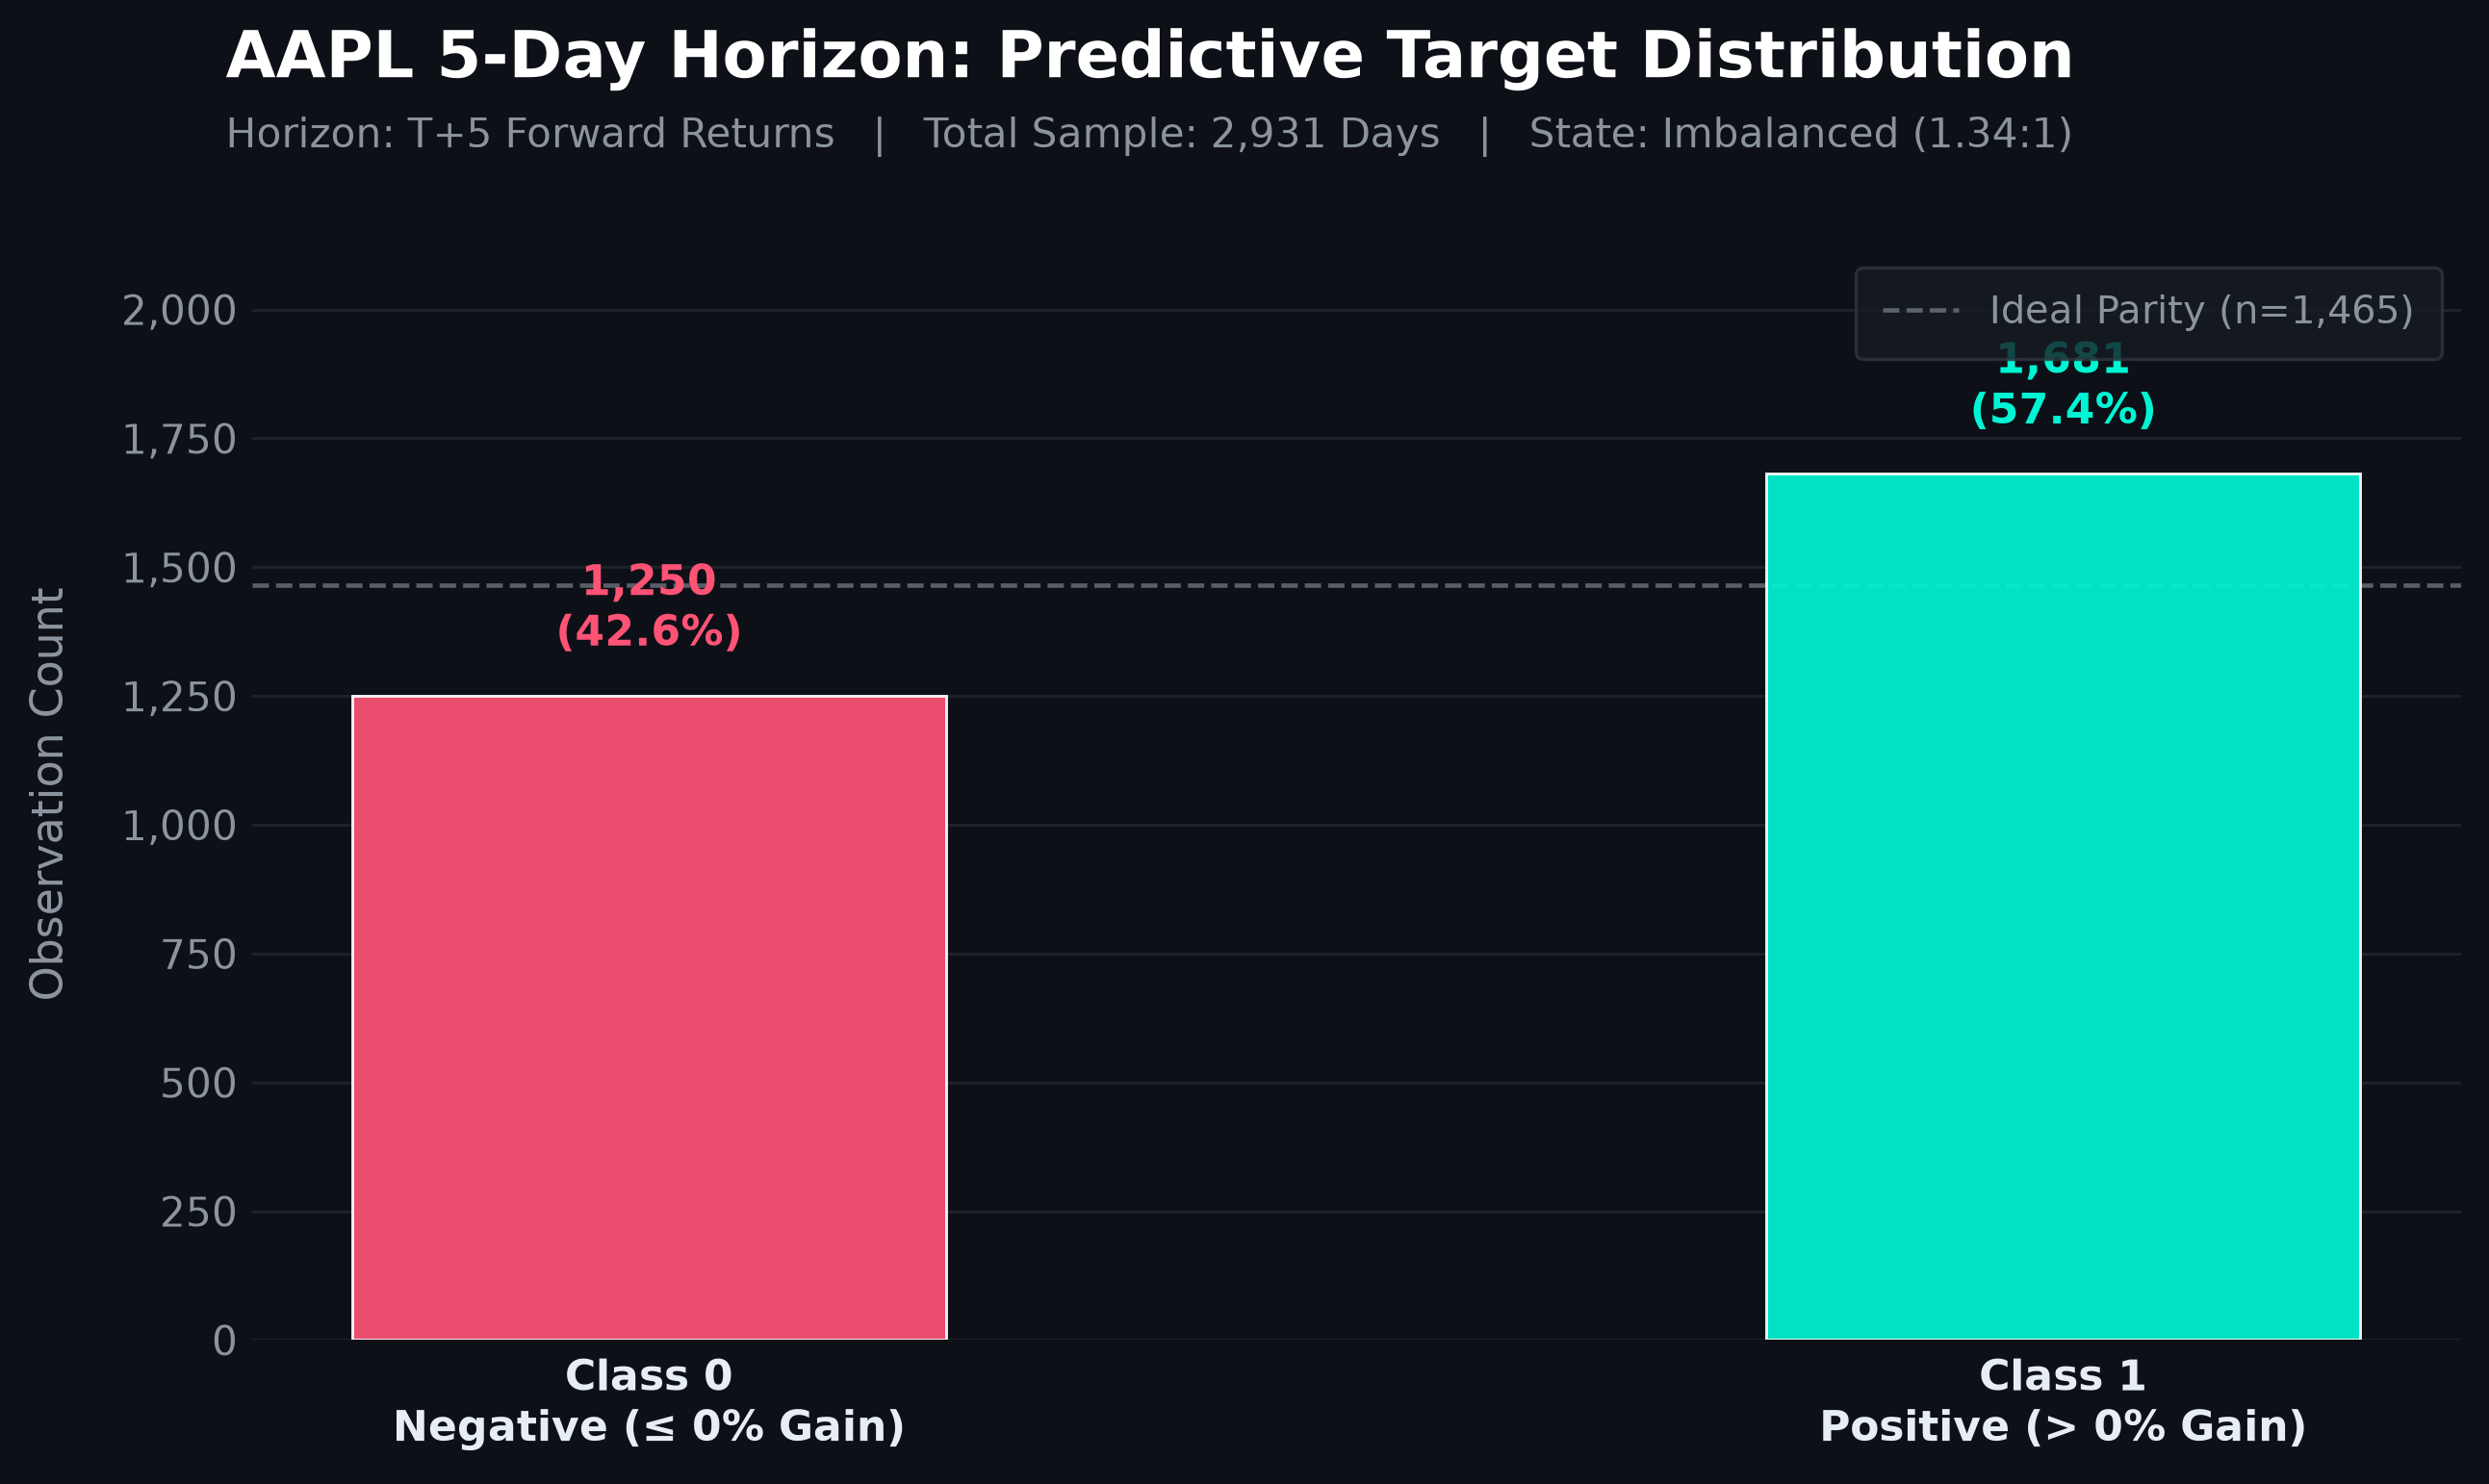

In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(9, 5.4), dpi=300)
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

target_series = features_df["target"].dropna().astype(int)
target_counts = target_series.value_counts().sort_index()
total_obs = len(target_series)
categories = [str(idx) for idx in target_counts.index]
counts = target_counts.values
percentages = (counts / total_obs) * 100

bar_colors = ["#FF5376", "#00F5D4"]

bars = ax.bar(
    categories,
    counts,
    width=0.42,
    color=bar_colors,
    edgecolor="#FFFFFF",
    linewidth=0.7,
    alpha=0.92,
    zorder=3,)

for bar, count, pct, col in zip(bars, counts, percentages, bar_colors):
    y_pos = bar.get_height()
    ax.annotate(
        f"{count:,}\n({pct:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, y_pos),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color=col,
        zorder=4,)

parity_level = total_obs / len(counts)
ax.axhline(
    parity_level,
    color="#8B949E",
    linestyle="--",
    linewidth=1.1,
    alpha=0.6,
    label=f"Ideal Parity (n={int(parity_level):,})",
    zorder=2,)

imbalance_ratio = max(counts) / min(counts) if min(counts) > 0 else 0
ratio_status = "Well-Balanced" if imbalance_ratio < 1.25 else f"Imbalanced ({imbalance_ratio:.2f}:1)"

fig.text(
    0.08,
    0.95,
    "AAPL 5-Day Horizon: Predictive Target Distribution",
    fontsize=16,
    fontweight="bold",
    color="#FFFFFF",
    ha="left",)
fig.text(
    0.08,
    0.905,
    f"Horizon: T+5 Forward Returns   |   Total Sample: {total_obs:,} Days   |   State: {ratio_status}",
    fontsize=10,
    color="#8B949E",
    ha="left",)

ax.grid(True, which="major", axis="y", color="#30363D", linestyle="-", linewidth=0.7, alpha=0.5)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="both", which="both", colors="#8B949E", labelsize=10, length=0)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("Observation Count", color="#8B949E", fontsize=11, labelpad=12)

custom_x_labels = [
    "Class 0\nNegative (≤ 0% Gain)",
    "Class 1\nPositive (> 0% Gain)",]
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(custom_x_labels, color="#E6EDF3", fontweight="semibold", fontsize=10.5)
ax.set_ylim(0, max(counts) * 1.26)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="#161B22",
    edgecolor="#30363D",
    fontsize=9.5,
    labelcolor="#8B949E",
    borderpad=0.7,)
legend.get_frame().set_linewidth(0.8)

plt.subplots_adjust(top=0.84, bottom=0.14, left=0.09, right=0.94)

EDA_DIR = Path("../results/eda")
EDA_DIR.mkdir(parents=True, exist_ok=True)

graph_path = EDA_DIR / "aapl_target_distribution.png"

plt.savefig(
    graph_path,
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",)

plt.show()

In [52]:
EDA_RESULTS_DIR = RESULTS_DIR / "eda"
EDA_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

missing_report.to_csv(
    EDA_RESULTS_DIR / "missing_value_report.csv")

outlier_report.to_csv(
    EDA_RESULTS_DIR / "outlier_report.csv",
    index=False)

target_distribution.to_csv(
    EDA_RESULTS_DIR / "target_distribution.csv")

print("EDA reports saved successfully")

EDA reports saved successfully


In [58]:
print("Final dataset shape:", features_df.shape)

print("\nDate range:")
print(features_df["date"].min(), "to", features_df["date"].max())

print("\nTarget distribution:")
display(features_df["target"].value_counts())

print("\nTarget percentage:")
display(
    features_df["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nMissing values in target:")
print(features_df["target"].isna().sum())

Final dataset shape: (2931, 291)

Date range:
2015-01-02 00:00:00 to 2026-08-28 00:00:00

Target distribution:


target
1    1681
0    1250
Name: count, dtype: int64


Target percentage:


target
1    57.35
0    42.65
Name: proportion, dtype: float64


Missing values in target:
0


In [59]:
display(
    features_df[
        [
            "date",
            "Close_AAPL",
            "future_return_5d",
            "target"]
    ].head(15))

,date,Close_AAPL,future_return_5d,target
0,2015-01-02,27.332500,0.024513,1
1,2015-01-05,26.562500,0.028235,1
2,2015-01-06,26.565001,0.037267,1
3,2015-01-07,26.937500,0.019026,1
4,2015-01-08,27.972500,-0.045312,0
5,2015-01-09,28.002501,-0.053745,0
6,2015-01-12,27.312500,-0.004851,0
7,2015-01-13,27.555000,-0.006079,0
8,2015-01-14,27.450001,0.023679,1
9,2015-01-15,26.705000,0.057667,1


In [60]:
target_check = (
    features_df["future_return_5d"] > 0
).astype(int)

print(
    "Target creation correct:",
    (target_check == features_df["target"]).all())

Target creation correct: True


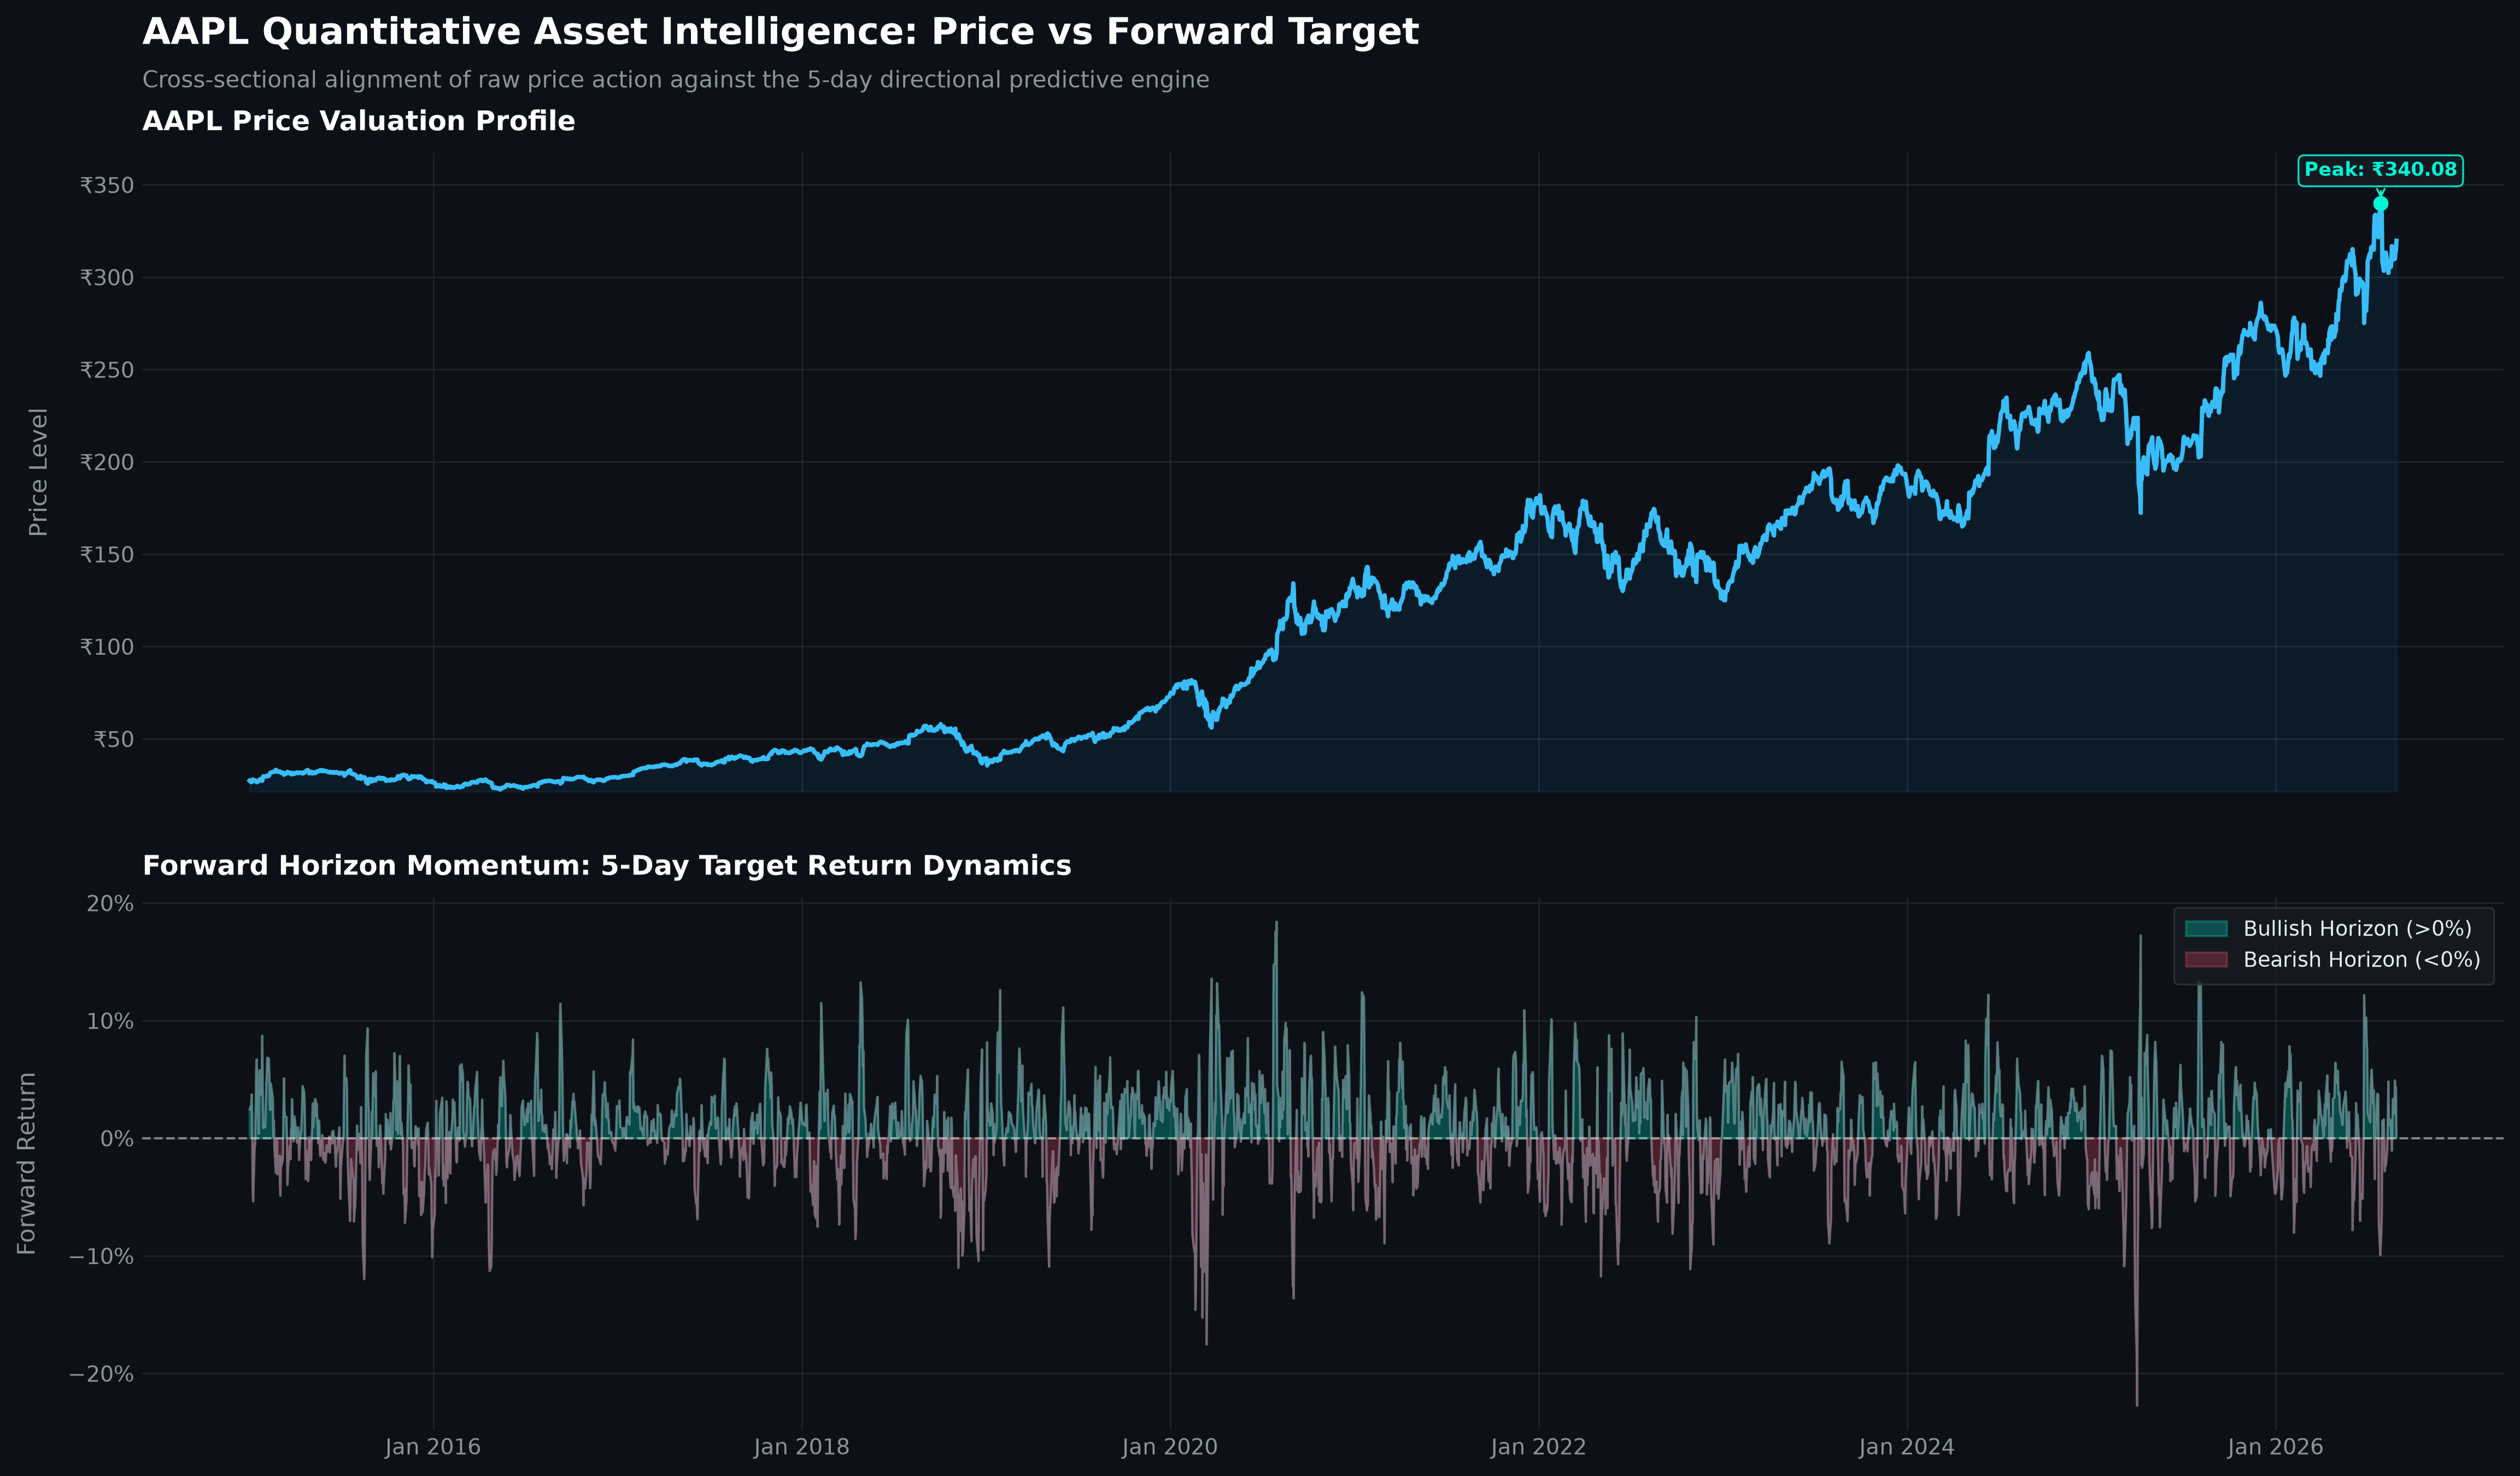

In [61]:
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

plt.style.use("dark_background")

date_col = "date"
price_col = (
    "Close_AAPL"
    if "Close_AAPL" in features_df.columns
    else "Adj Close_AAPL")
return_col = "future_return_5d"

features_df[date_col] = pd.to_datetime(features_df[date_col])

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(16, 9.5),
    dpi=300,
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1]},)
fig.patch.set_facecolor("#0D1117")
ax1.set_facecolor("#0D1117")
ax2.set_facecolor("#0D1117")

sky_blue = "#38BDF8"
emerald_green = "#00F5D4"
coral_red = "#FF5376"

# PANEL 1: AAPL Close Price Action
ax1.plot(
    features_df[date_col],
    features_df[price_col],
    color=sky_blue,
    linewidth=1.9,
    label="AAPL Price Level",
    zorder=3,)

y1_floor = features_df[price_col].min() * 0.94
ax1.fill_between(
    features_df[date_col],
    features_df[price_col],
    y1_floor,
    color="#0284C7",
    alpha=0.10,
    zorder=2,)

max_idx = features_df[price_col].idxmax()
max_d, max_v = features_df.loc[max_idx, date_col], features_df.loc[max_idx, price_col]
ax1.scatter([max_d], [max_v], color=emerald_green, s=32, zorder=5)
ax1.annotate(
    f"Peak: ₹{max_v:,.2f}",
    xy=(max_d, max_v),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
    fontsize=8.5,
    fontweight="bold",
    color=emerald_green,
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="#161B22",
        ec=emerald_green,
        lw=0.8,
        alpha=0.9,
    ),
    arrowprops=dict(arrowstyle="->", color=emerald_green, lw=0.8),
    zorder=6,)

ax1.set_title(
    "AAPL Price Valuation Profile",
    fontsize=12,
    fontweight="bold",
    color="#FFFFFF",
    loc="left",
    pad=10,)
ax1.set_ylabel("Price Level", color="#8B949E", fontsize=10.5, labelpad=12)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("₹{x:,.0f}"))
ax1.set_ylim(y1_floor, features_df[price_col].max() * 1.08)

# PANEL 2: Future 5-Day Horizon Returns
ret_series = features_df[return_col]

scale = 100 if ret_series.dropna().abs().max() <= 1.5 else 1
scaled_ret = ret_series * scale

ax2.plot(
    features_df[date_col],
    scaled_ret,
    color="#8B949E",
    linewidth=1.0,
    alpha=0.6,
    zorder=3,)

ax2.fill_between(
    features_df[date_col],
    scaled_ret,
    0,
    where=(scaled_ret >= 0),
    color=emerald_green,
    alpha=0.25,
    interpolate=True,
    zorder=2,
    label="Bullish Horizon (>0%)",)
ax2.fill_between(
    features_df[date_col],
    scaled_ret,
    0,
    where=(scaled_ret < 0),
    color=coral_red,
    alpha=0.25,
    interpolate=True,
    zorder=2,
    label="Bearish Horizon (<0%)",)

ax2.axhline(0, color="#E6EDF3", linestyle="--", linewidth=1.0, alpha=0.5, zorder=4)

ax2.set_title(
    "Forward Horizon Momentum: 5-Day Target Return Dynamics",
    fontsize=12,
    fontweight="bold",
    color="#FFFFFF",
    loc="left",
    pad=10,)
ax2.set_ylabel("Forward Return", color="#8B949E", fontsize=10.5, labelpad=12)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=0))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Global Layout, Spines & Save Routine
for ax in (ax1, ax2):
    ax.grid(
        True,
        which="major",
        color="#30363D",
        linestyle="-",
        linewidth=0.65,
        alpha=0.5,)
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(
        axis="both", which="both", colors="#8B949E", labelsize=9.5, length=0)

legend = ax2.legend(
    loc="upper right",
    frameon=True,
    facecolor="#161B22",
    edgecolor="#30363D",
    fontsize=9,
    labelcolor="#E6EDF3",
    borderpad=0.6,)
legend.get_frame().set_linewidth(0.8)

fig.text(
    0.06,
    0.97,
    "AAPL Quantitative Asset Intelligence: Price vs Forward Target",
    fontsize=16,
    fontweight="bold",
    color="#FFFFFF",
    ha="left",)
fig.text(
    0.06,
    0.942,
    "Cross-sectional alignment of raw price action against the 5-day directional predictive engine",
    fontsize=10,
    color="#8B949E",
    ha="left",)

plt.subplots_adjust(
    top=0.90, bottom=0.08, left=0.06, right=0.96, hspace=0.18)

EDA_DIR = (
    Path("../results/eda")
    if Path("../results").exists()
    else Path("results/eda"))
EDA_DIR.mkdir(parents=True, exist_ok=True)

graph_path = EDA_DIR / "aapl_price_and_target_dynamics.png"
plt.savefig(
    graph_path,
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",)
plt.show()
plt.close()

In [62]:
feature_candidates = [
    "Features_AAPL_return_1d",
    "Features_AAPL_return_5d",
    "Features_AAPL_return_20d",
    "Features_AAPL_return_60d",
    "Features_AAPL_log_return",
    "Features_AAPL_price_to_ma20",
    "Features_AAPL_price_to_ma50",
    "Features_AAPL_price_to_ma200",
    "Features_market_return_1d",
    "Features_market_return_5d",
    "Features_market_return_20d"]

available_features = [
    column
    for column in feature_candidates
    if column in features_df.columns]

target_feature_summary = (
    features_df
    .groupby("target")[available_features]
    .mean()
    .T)

display(target_feature_summary)

target,0,1
Features_AAPL_return_1d,0.000763,0.001255
Features_AAPL_return_5d,0.003730,0.006200
Features_AAPL_return_20d,0.015782,0.024180
Features_AAPL_return_60d,0.060310,0.062197
Features_AAPL_log_return,0.000588,0.001100
Features_AAPL_price_to_ma20,1.005702,1.010957
Features_AAPL_price_to_ma50,1.018915,1.024328
Features_AAPL_price_to_ma200,1.094750,1.091184
Features_market_return_1d,0.000356,0.000630
Features_market_return_5d,0.002384,0.002648


In [63]:
target_feature_summary["difference_1_minus_0"] = (
    target_feature_summary[1]
    - target_feature_summary[0])

display(
    target_feature_summary
    .sort_values(
        "difference_1_minus_0",
        key=abs,
        ascending=False))

target,0,1,difference_1_minus_0
Features_AAPL_return_20d,0.015782,0.024180,0.008397
Features_AAPL_price_to_ma50,1.018915,1.024328,0.005413
Features_AAPL_price_to_ma20,1.005702,1.010957,0.005256
Features_market_return_20d,0.007787,0.011983,0.004197
Features_AAPL_price_to_ma200,1.094750,1.091184,-0.003566
Features_AAPL_return_5d,0.003730,0.006200,0.002470
Features_AAPL_return_60d,0.060310,0.062197,0.001887
Features_AAPL_log_return,0.000588,0.001100,0.000512
Features_AAPL_return_1d,0.000763,0.001255,0.000492
Features_market_return_1d,0.000356,0.000630,0.000274


In [64]:
leakage_keywords = [
    "future",
    "target",
    "label",
    "forward",
    "next",
    "lead"]

possible_leakage_columns = [
    column
    for column in features_df.columns
    if any(
        keyword in column.lower()
        for keyword in leakage_keywords
    )]

print("Possible leakage columns:")
for column in possible_leakage_columns:
    print(column)

Possible leakage columns:
target
future_return_5d


In [65]:
MODEL_DATA_DIR = DATA_DIR / "processed"
MODEL_DATA_DIR.mkdir(parents=True, exist_ok=True)

features_df.to_parquet(
    MODEL_DATA_DIR / "aapl_features_with_target.parquet",
    index=False)

print("Modeling dataset saved successfully ")
print(
    MODEL_DATA_DIR / "aapl_features_with_target.parquet")

Modeling dataset saved successfully 
c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\processed\aapl_features_with_target.parquet
